# Causal Machine Learning — Entrega Intermediária
## Prevenção de Churn em Telecomunicações via Inferência Causal

**Grupo:** Eduardo Assis Tomich · Lucas Augusto da Silva Gonçalves · Lucas Vitor da Silva Ramos · Rafael Vinícius dos Santos

**Disciplina:** Causal Machine Learning — UFMG 2026/1

---

### Contexto do Problema

No setor de telecomunicações, o custo de aquisição de clientes (CAC) supera significativamente o de retenção, tornando o *churn* um desafio crítico. Modelos preditivos tradicionais identificam clientes com alto risco de cancelamento, mas **não prescrevem a ação ideal**.

O projeto completo formula a prevenção de churn como um problema de **Unit Selection** (Pearl, Nível 3), onde o objetivo é identificar *Compliers* — clientes que só permanecerão se receberem um tratamento específico.

### Formulação das Variáveis

| Símbolo | Descrição | Variáveis no Dataset |
|---------|-----------|---------------------|
| **C** (Covariáveis) | Atributos observáveis do cliente | `tenure`, `Contract`, `MonthlyCharges`, `gender`, `SeniorCitizen`, `Partner`, `Dependents`, `InternetService`, etc. |
| **X** (Tratamentos) | Intervenções de retenção | `TechSupport`, `StreamingTV`, `StreamingMovies` |
| **Y** (Desfecho) | Retenção do cliente | `Churn` invertido: **Y=1 → Ficou**, **Y=0 → Cancelou** |

### Escopo desta Entrega

1. Limpeza e preparação dos dados
2. Análise Exploratória de Dados (EDA)
3. Modelos preditivos baseline (Regressão Logística + Random Forest)
4. DAG Causal do problema

---
## 1. Setup e Carregamento dos Dados

In [1]:
%pip install -q kagglehub pandas numpy matplotlib seaborn scikit-learn networkx

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    average_precision_score,
    PrecisionRecallDisplay,
    brier_score_loss,
)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42

import warnings  # 4.9: silenciar FutureWarnings ruidosos

warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
import kagglehub

path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print(f"Dataset baixado em: {path}")

Dataset baixado em: C:\Users\lucas\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


In [4]:
import os

csv_file = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")
df_raw = pd.read_csv(csv_file)

print(f"Shape: {df_raw.shape}")
print(f"Colunas: {list(df_raw.columns)}")
df_raw.head()

Shape: (7043, 21)
Colunas: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


---
## 2. Limpeza de Dados

Problemas conhecidos do dataset:
- `TotalCharges` está como `object` (strings vazias em clientes com `tenure=0`)
- `customerID` não é feature útil
- `Churn` precisa ser convertido para numérico com Y=1 representando **retenção**

In [6]:
df = df_raw.copy()

# Remover customerID
df = df.drop(columns=["customerID"])

# Converter TotalCharges para numérico
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Verificar nulos gerados pela conversão
nulos_tc = df["TotalCharges"].isna().sum()
print(f"Valores nulos em TotalCharges após conversão: {nulos_tc}")
print(f"Esses clientes têm tenure = 0:")
df[df["TotalCharges"].isna()][["tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

Valores nulos em TotalCharges após conversão: 11
Esses clientes têm tenure = 0:


,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


In [7]:
# Clientes com tenure=0 e TotalCharges nulo: preencher com 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Criar variável target Y: 1 = Retenção (No Churn), 0 = Cancelou (Churn)
df["Y"] = (df["Churn"] == "No").astype(int)
df = df.drop(columns=["Churn"])

print(f"Distribuição de Y (1=Ficou, 0=Cancelou):")
print(df["Y"].value_counts())
print(f"\nNulos restantes por coluna:")
print(df.isnull().sum()[df.isnull().sum() > 0])
if df.isnull().sum().sum() == 0:
    print("Nenhum valor nulo restante.")

Distribuição de Y (1=Ficou, 0=Cancelou):
Y
1    5174
0    1869
Name: count, dtype: int64

Nulos restantes por coluna:
Series([], dtype: int64)
Nenhum valor nulo restante.


In [8]:
# Definir grupos de variáveis conforme a formulação do projeto
TREATMENTS = ["TechSupport", "StreamingTV", "StreamingMovies"]
TARGET = "Y"

COVARIATES = [col for col in df.columns if col not in TREATMENTS + [TARGET]]

print(f"Covariáveis (C): {COVARIATES}")
print(f"Tratamentos (X): {TREATMENTS}")
print(f"Desfecho (Y): {TARGET}")

Covariáveis (C): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']
Tratamentos (X): ['TechSupport', 'StreamingTV', 'StreamingMovies']
Desfecho (Y): Y


In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Y
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304,0.734630
std,0.368612,24.559481,30.090047,2266.794470,0.441561
min,0.000000,0.000000,18.250000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,398.550000,0.000000
50%,0.000000,29.000000,70.350000,1394.550000,1.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


In [10]:
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Y                     int64
dtype: object

---
## 3. Análise Exploratória de Dados (EDA)

### 3.1 Distribuição do Target (Retenção vs. Churn)

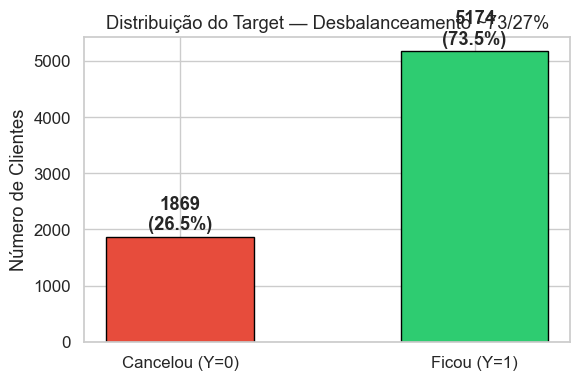

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df["Y"].value_counts()
labels = ["Cancelou (Y=0)", "Ficou (Y=1)"]
colors = ["#e74c3c", "#2ecc71"]
bars = ax.bar(
    labels, [counts[0], counts[1]], color=colors, edgecolor="black", width=0.5
)

for bar, count in zip(bars, [counts[0], counts[1]]):
    pct = count / len(df) * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{count}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

ax.set_ylabel("Número de Clientes")
ax.set_title("Distribuição do Target — Desbalanceamento ~73/27%")
plt.tight_layout()
plt.show()

### 3.2 Features Demográficas vs. Retenção

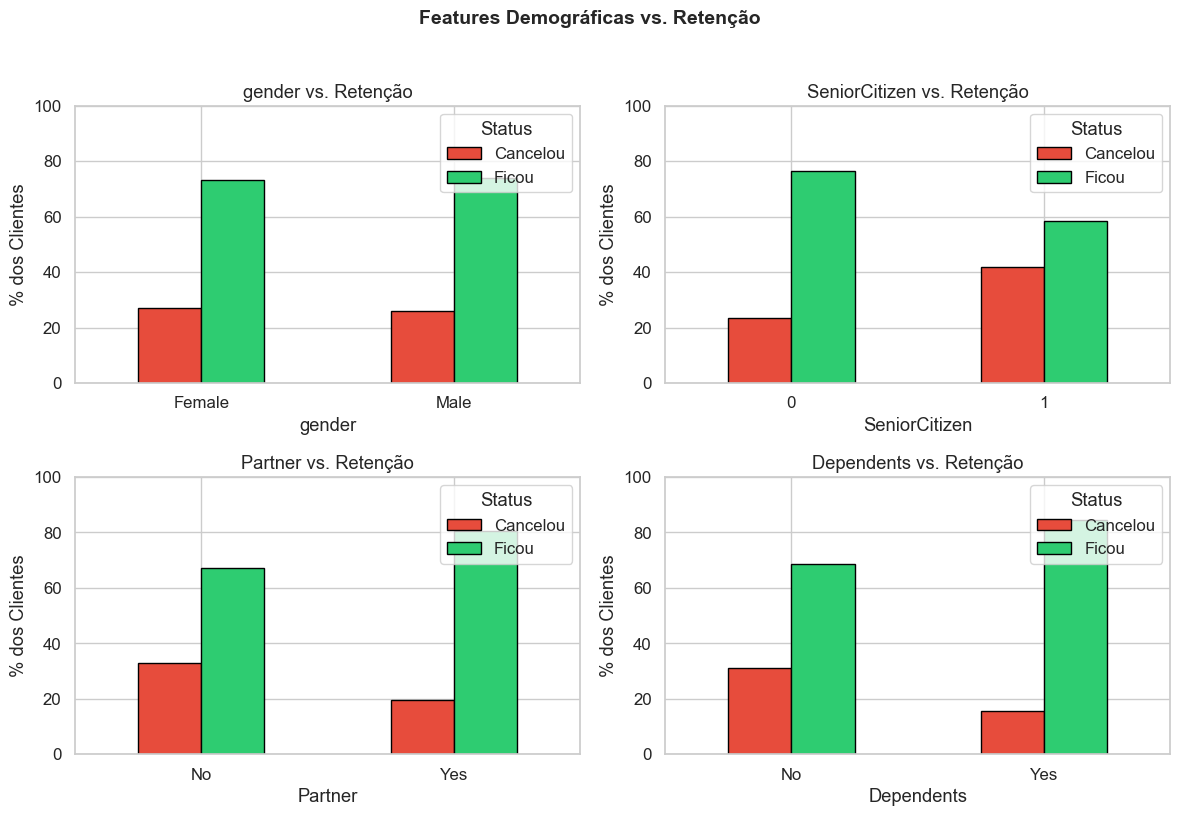

In [12]:
demo_features = ["gender", "SeniorCitizen", "Partner", "Dependents"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feat in enumerate(demo_features):
    ax = axes[i]
    ct = pd.crosstab(df[feat], df["Y"], normalize="index") * 100
    ct.columns = ["Cancelou", "Ficou"]
    ct.plot(kind="bar", ax=ax, color=["#e74c3c", "#2ecc71"], edgecolor="black", rot=0)
    ax.set_title(f"{feat} vs. Retenção")
    ax.set_ylabel("% dos Clientes")
    ax.set_xlabel(feat)
    ax.legend(title="Status", loc="upper right")
    ax.set_ylim(0, 100)

plt.suptitle(
    "Features Demográficas vs. Retenção", fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()

### 3.3 Features de Conta vs. Retenção

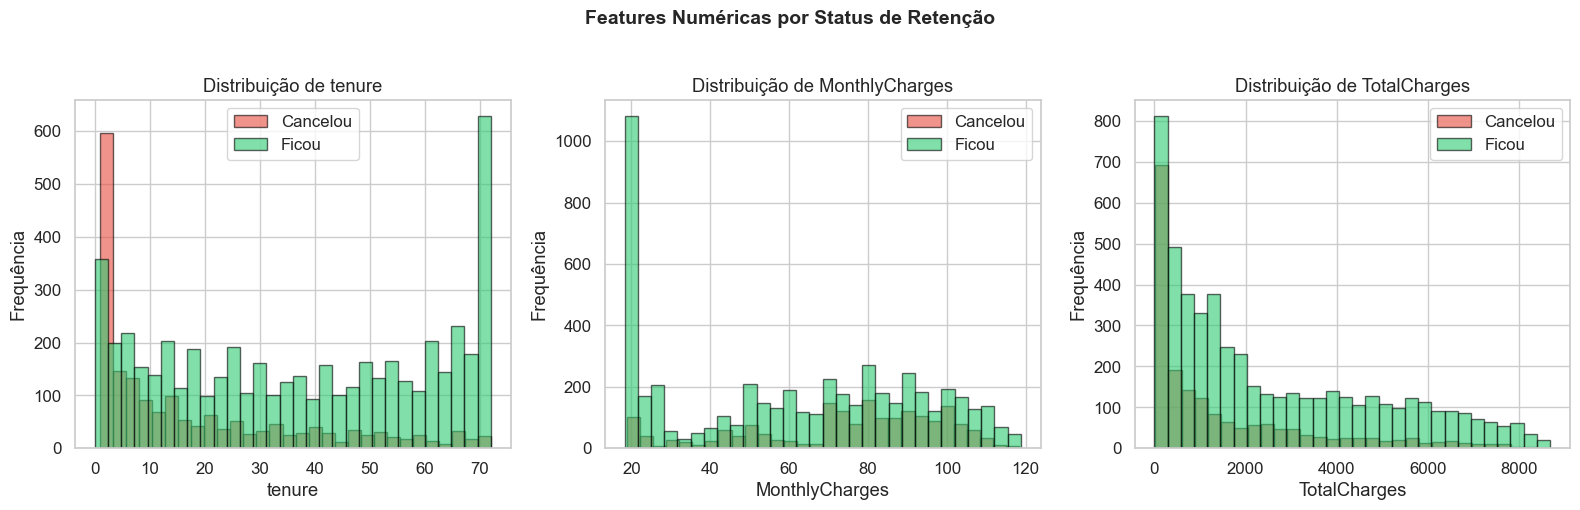

In [13]:
num_features = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, feat in enumerate(num_features):
    ax = axes[i]
    for y_val, label, color in [(0, "Cancelou", "#e74c3c"), (1, "Ficou", "#2ecc71")]:
        subset = df[df["Y"] == y_val][feat]
        ax.hist(subset, bins=30, alpha=0.6, label=label, color=color, edgecolor="black")
    ax.set_title(f"Distribuição de {feat}")
    ax.set_xlabel(feat)
    ax.set_ylabel("Frequência")
    ax.legend()

plt.suptitle(
    "Features Numéricas por Status de Retenção", fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()

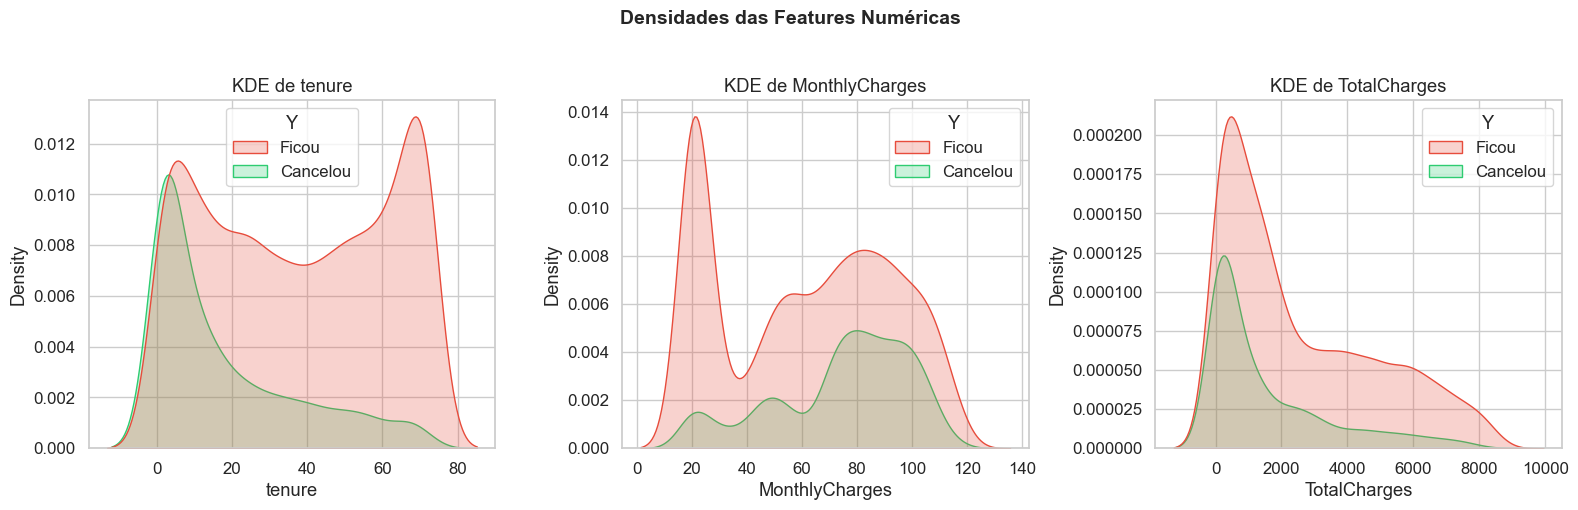

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, feat in enumerate(num_features):
    ax = axes[i]
    sns.kdeplot(
        data=df,
        x=feat,
        hue=df["Y"].map({0: "Cancelou", 1: "Ficou"}),
        fill=True,
        ax=ax,
        palette=["#e74c3c", "#2ecc71"],
    )
    ax.set_title(f"KDE de {feat}")

plt.suptitle(
    "Densidades das Features Numéricas", fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()

### 3.4 Features de Serviço vs. Retenção

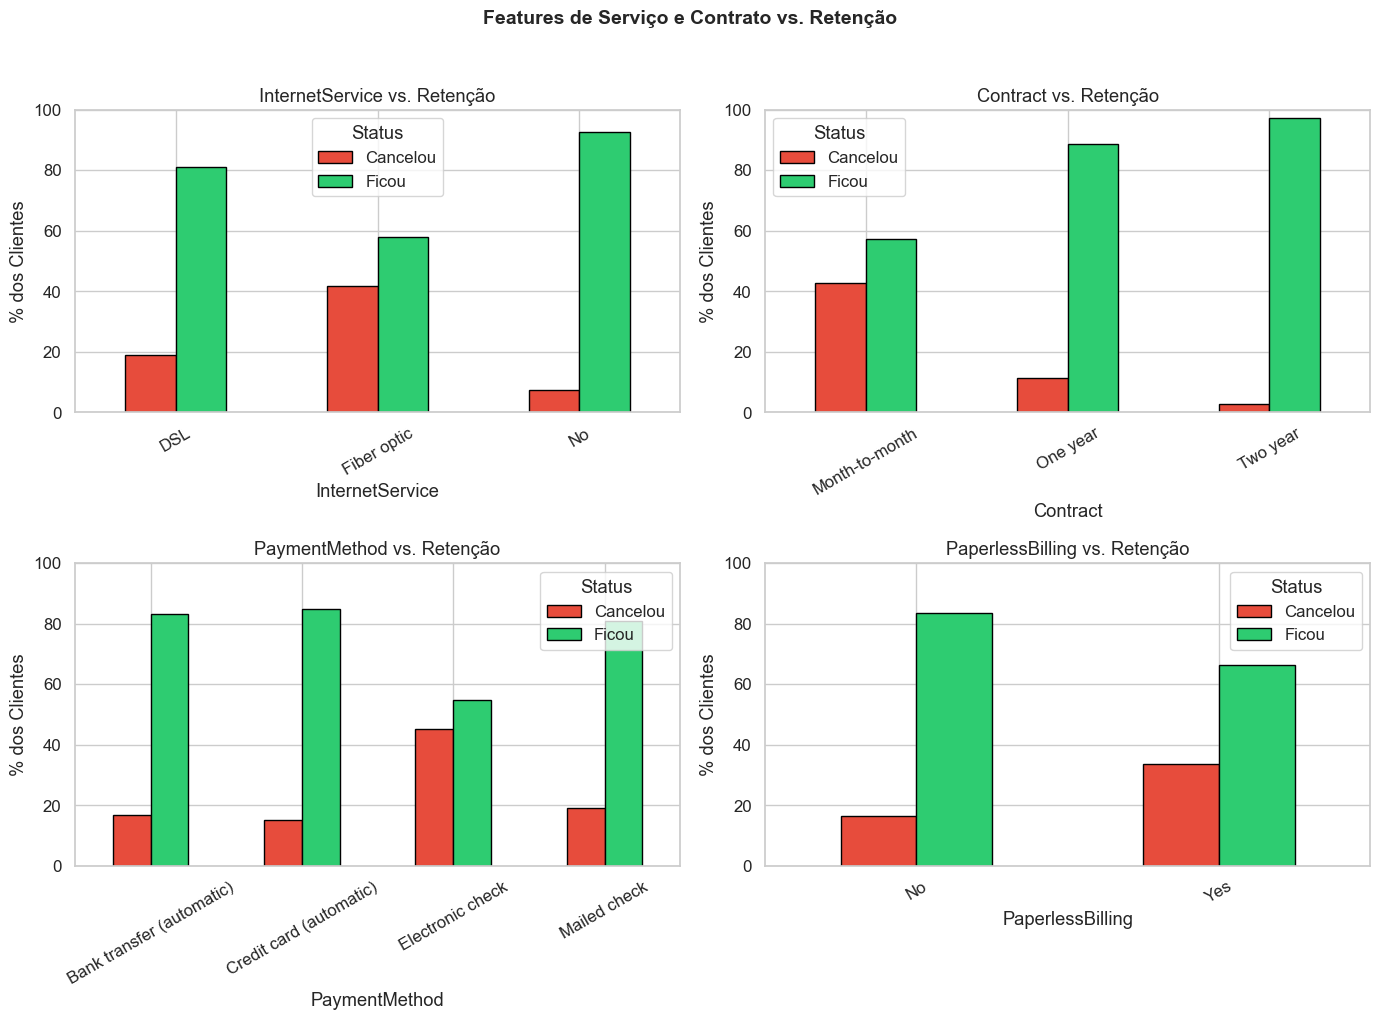

In [15]:
service_features = ["InternetService", "Contract", "PaymentMethod", "PaperlessBilling"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(service_features):
    ax = axes[i]
    ct = pd.crosstab(df[feat], df["Y"], normalize="index") * 100
    ct.columns = ["Cancelou", "Ficou"]
    ct.plot(kind="bar", ax=ax, color=["#e74c3c", "#2ecc71"], edgecolor="black", rot=30)
    ax.set_title(f"{feat} vs. Retenção")
    ax.set_ylabel("% dos Clientes")
    ax.set_xlabel(feat)
    ax.legend(title="Status")
    ax.set_ylim(0, 100)

plt.suptitle(
    "Features de Serviço e Contrato vs. Retenção",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

### 3.5 Variáveis de Tratamento (X) vs. Retenção

Estas são as variáveis de tratamento do projeto: `TechSupport`, `StreamingTV`, `StreamingMovies`. Na entrega final, estimaremos o efeito causal (CATE) de cada uma sobre a retenção. Aqui analisamos a **associação observacional** — que inclui confundimento e não deve ser interpretada como efeito causal.

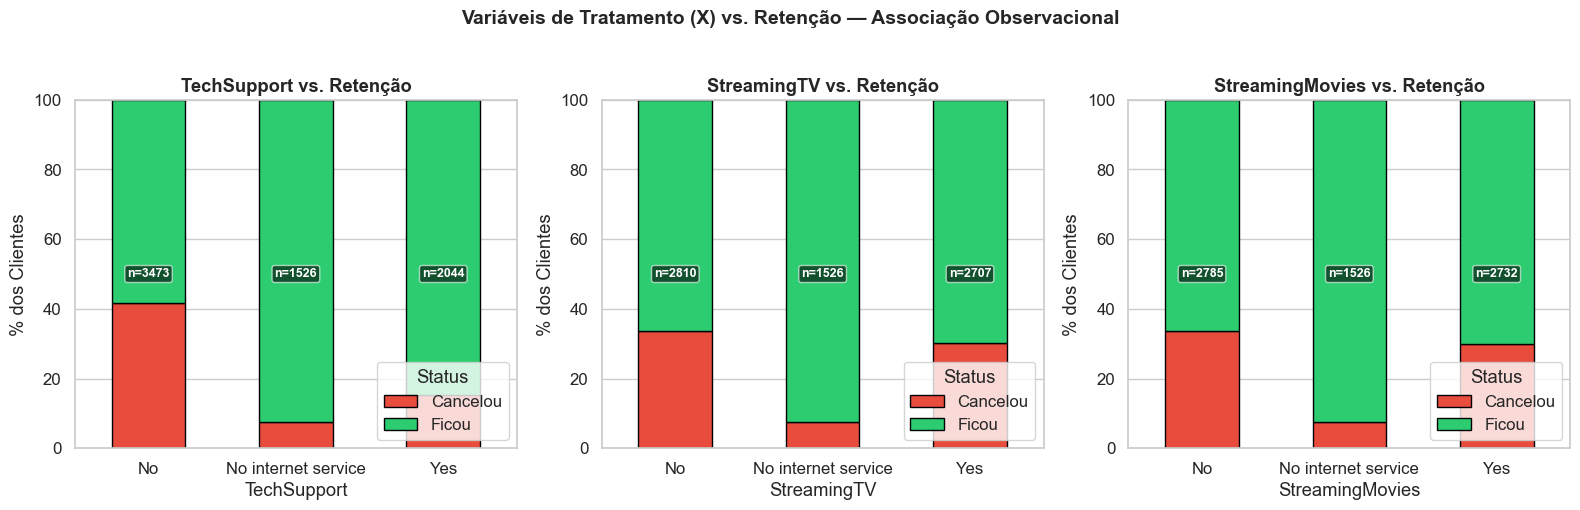

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, treat in enumerate(TREATMENTS):
    ax = axes[i]
    ct = pd.crosstab(df[treat], df["Y"])
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.columns = ["Cancelou", "Ficou"]

    ct_pct.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=["#e74c3c", "#2ecc71"],
        edgecolor="black",
        rot=0,
    )
    ax.set_title(f"{treat} vs. Retenção", fontweight="bold")
    ax.set_ylabel("% dos Clientes")
    ax.set_xlabel(treat)
    ax.legend(title="Status", loc="lower right")
    ax.set_ylim(0, 100)

    # Anotar contagens
    for j, (idx, row) in enumerate(ct_pct.iterrows()):
        total = ct.loc[idx].sum()
        ax.text(
            j,
            50,
            f"n={total}",
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold",
            color="white",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="black", alpha=0.6),
        )

plt.suptitle(
    "Variáveis de Tratamento (X) vs. Retenção — Associação Observacional",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

In [17]:
# Taxa de retenção bruta por tratamento (associação, não causal)
print("Taxa de retenção (Y=1) por valor de cada tratamento:\n")
for treat in TREATMENTS:
    rates = df.groupby(treat)["Y"].mean().round(3)
    print(f"--- {treat} ---")
    for val, rate in rates.items():
        print(f"  {val}: {rate:.1%} de retenção")
    print()

Taxa de retenção (Y=1) por valor de cada tratamento:

--- TechSupport ---
  No: 58.4% de retenção
  No internet service: 92.6% de retenção
  Yes: 84.8% de retenção

--- StreamingTV ---
  No: 66.5% de retenção
  No internet service: 92.6% de retenção
  Yes: 69.9% de retenção

--- StreamingMovies ---
  No: 66.3% de retenção
  No internet service: 92.6% de retenção
  Yes: 70.1% de retenção



### 3.5.1 Prova Empírica do Viés de Seleção

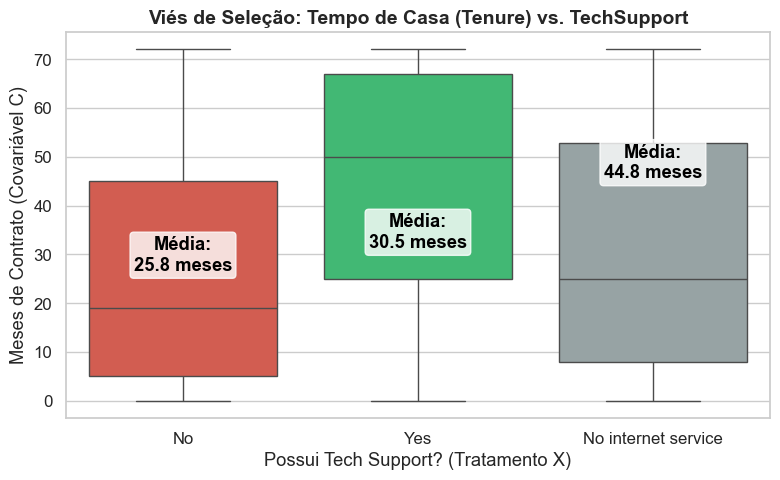

In [18]:
# Clientes com Suporte Técnico tendem a ter contratos muito mais antigos.

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="TechSupport",
    y="tenure",
    palette={"No": "#e74c3c", "Yes": "#2ecc71", "No internet service": "#95a5a6"},
    ax=ax,
)

ax.set_title(
    "Viés de Seleção: Tempo de Casa (Tenure) vs. TechSupport",
    fontsize=14,
    fontweight="bold",
)
ax.set_xlabel("Possui Tech Support? (Tratamento X)")
ax.set_ylabel("Meses de Contrato (Covariável C)")

# Anotação das médias
medias = df.groupby("TechSupport")["tenure"].mean()
for i, key in enumerate(["No", "No internet service", "Yes"]):
    ax.text(
        i,
        medias[key],
        f"Média:\n{medias[key]:.1f} meses",
        ha="center",
        va="bottom",
        fontweight="bold",
        color="black",
        bbox=dict(facecolor="white", alpha=0.8, boxstyle="round,pad=0.2"),
    )

plt.tight_layout()
plt.show()

### 3.6 Matriz de Correlação

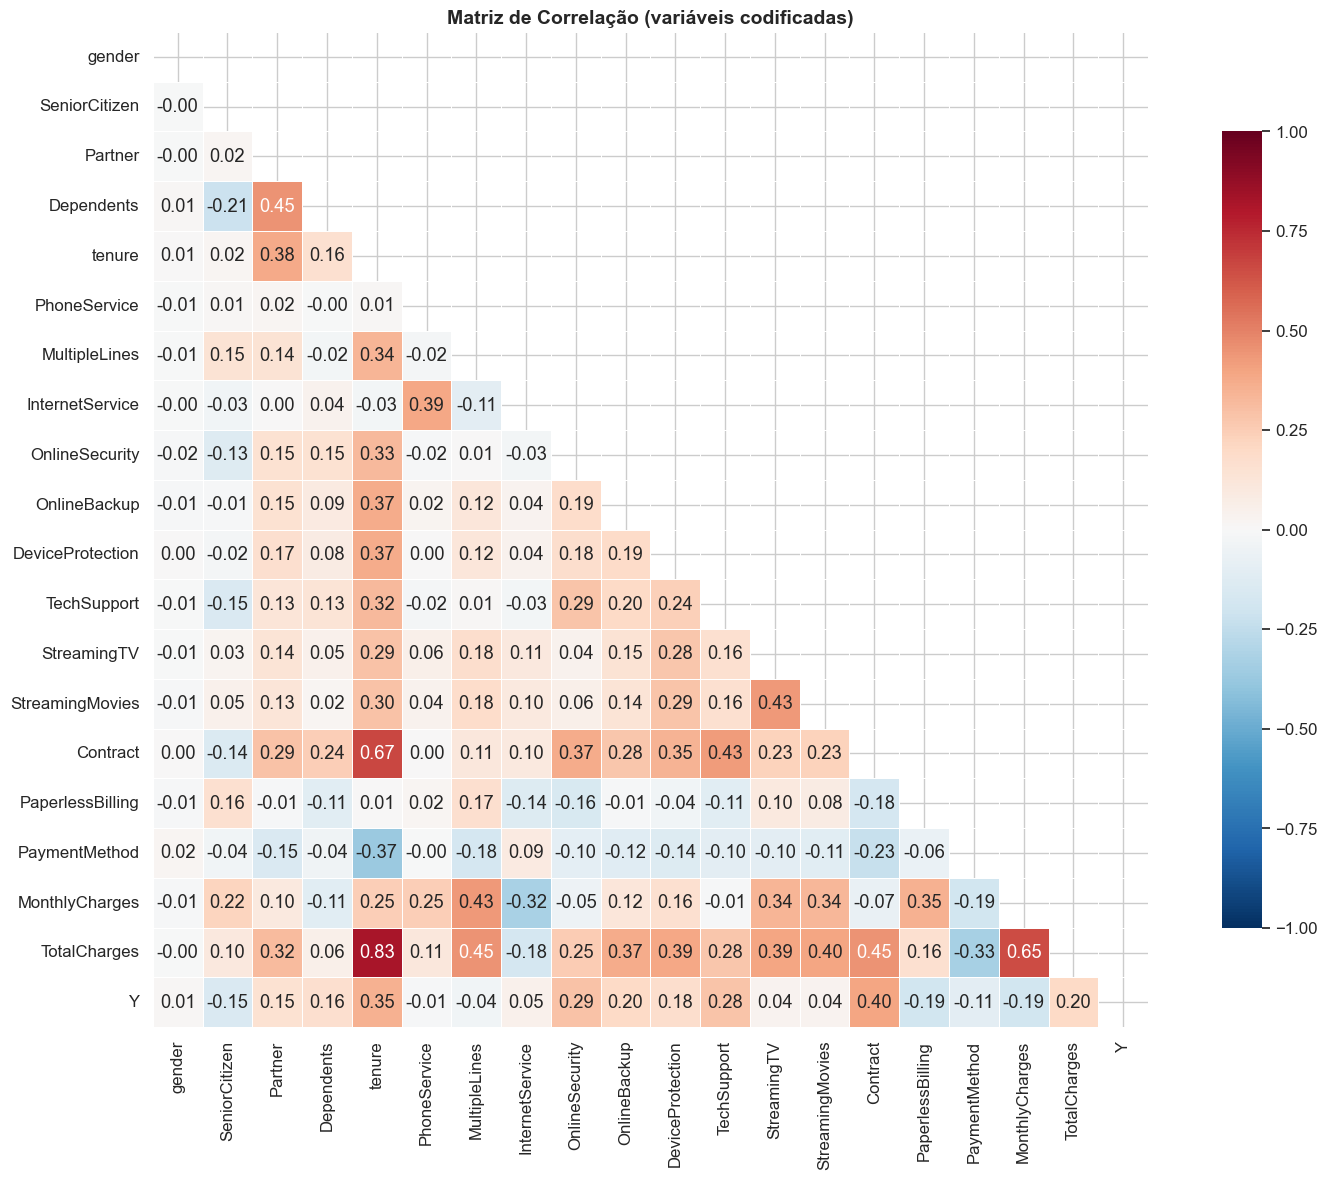

In [19]:
# Codificar variáveis categóricas para a correlação
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include="object").columns:
    df_encoded[col] = df_encoded[col].astype("category").cat.codes

fig, ax = plt.subplots(figsize=(16, 12))
corr = df_encoded.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
ax.set_title(
    "Matriz de Correlação (variáveis codificadas)", fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()

In [20]:
# Correlações mais fortes com Y
corr_with_y = corr["Y"].drop("Y").sort_values(key=abs, ascending=False)
print("Top correlações com Y (Retenção):\n")
print(corr_with_y.head(10).to_string())

Top correlações com Y (Retenção):

Contract            0.396713
tenure              0.352229
OnlineSecurity      0.289309
TechSupport         0.282492
TotalCharges        0.198324
OnlineBackup        0.195525
MonthlyCharges     -0.193356
PaperlessBilling   -0.191825
DeviceProtection    0.178134
Dependents          0.164221


---
## 4. Pré-processamento para Modelos de ML

Para os modelos preditivos baseline, usamos **todas as features** (C + X) para prever Y. O objetivo aqui é avaliar a capacidade preditiva, não o efeito causal — essa distinção será central na entrega final.

In [21]:
# Separar features e target
X = df.drop(columns=[TARGET])
y = df[TARGET]

# One-hot encoding das categóricas
X = pd.get_dummies(X, drop_first=True)

print(f"Features após encoding: {X.shape[1]} colunas")
print(f"Exemplos: {list(X.columns[:10])} ...")

Features após encoding: 30 colunas
Exemplos: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes'] ...


In [22]:
# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras (Y=1: {y_train.mean():.1%})")
print(f"Teste:  {X_test.shape[0]} amostras (Y=1: {y_test.mean():.1%})")

Treino: 5634 amostras (Y=1: 73.5%)
Teste:  1409 amostras (Y=1: 73.5%)


In [23]:
# Padronizar features numéricas
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Features numéricas padronizadas.")
X_train[num_cols].describe().round(2)

Features numéricas padronizadas.


,tenure,MonthlyCharges,TotalCharges
count,5634.00,5634.00,5634.00
mean,0.00,-0.00,0.00
std,1.00,1.00,1.00
min,-1.31,-1.56,-1.00
25%,-0.99,-0.95,-0.83
50%,-0.13,0.18,-0.39
75%,0.96,0.83,0.67
max,1.61,1.80,2.82


---
## 5. Modelos Preditivos Baseline

Treinamos dois modelos simples para estabelecer um baseline preditivo. As métricas escolhidas seguem a seção 9 do projeto:

- **PR-AUC** (Precision-Recall AUC): preferível ao ROC-AUC devido ao desbalanceamento. Calculado em relação à classe minoritária (Cancelou, Y=0).
- **Brier Score**: avalia a calibração das probabilidades — fundamental para a estimação de CATE na entrega final.

### 5.1 Regressão Logística

In [24]:
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

# PR-AUC calculado para a classe minoritária (Y=0 = Cancelou)
# average_precision_score por padrão calcula para pos_label=1,
# então invertemos para focar na classe minoritária
pr_auc_lr = average_precision_score(y_test, 1 - y_prob_lr, pos_label=0)
brier_lr = brier_score_loss(y_test, y_prob_lr)

print("=" * 50)
print("REGRESSÃO LOGÍSTICA")
print("=" * 50)
print(f"PR-AUC (classe minoritária): {pr_auc_lr:.4f}")
print(f"Brier Score:                 {brier_lr:.4f}")
print()
print(
    classification_report(y_test, y_pred_lr, target_names=["Cancelou (0)", "Ficou (1)"])
)

REGRESSÃO LOGÍSTICA
PR-AUC (classe minoritária): 0.6096
Brier Score:                 0.1415

              precision    recall  f1-score   support

Cancelou (0)       0.64      0.52      0.57       374
   Ficou (1)       0.84      0.89      0.86      1035

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



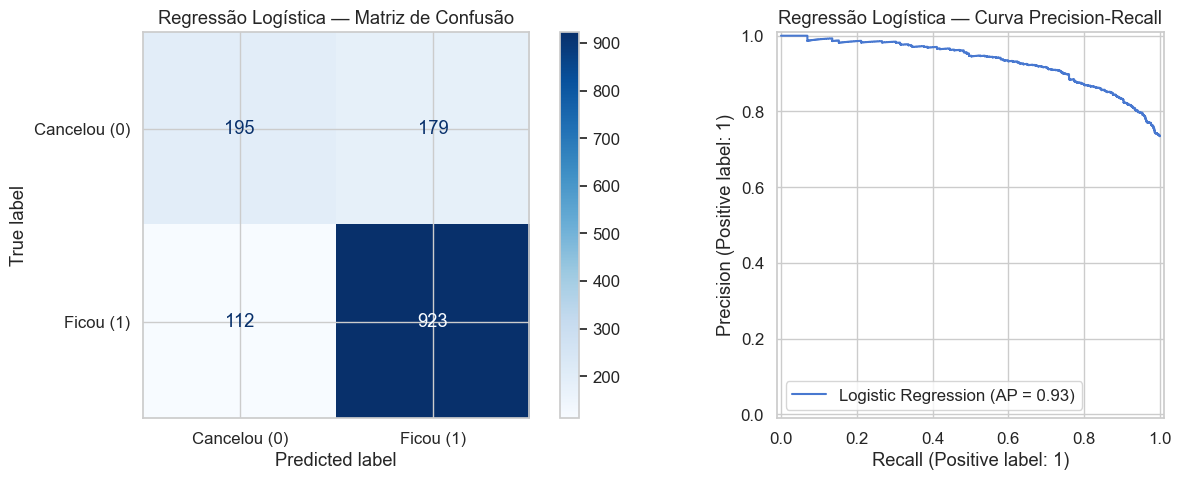

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusão
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=["Cancelou (0)", "Ficou (1)"],
    cmap="Blues",
    ax=axes[0],
)
axes[0].set_title("Regressão Logística — Matriz de Confusão")

# Curva Precision-Recall
PrecisionRecallDisplay.from_predictions(
    y_test, y_prob_lr, pos_label=1, name="Logistic Regression", ax=axes[1]
)
axes[1].set_title("Regressão Logística — Curva Precision-Recall")

plt.tight_layout()
plt.show()

### 5.2 Random Forest

In [26]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

pr_auc_rf = average_precision_score(y_test, 1 - y_prob_rf, pos_label=0)
brier_rf = brier_score_loss(y_test, y_prob_rf)

print("=" * 50)
print("RANDOM FOREST")
print("=" * 50)
print(f"PR-AUC (classe minoritária): {pr_auc_rf:.4f}")
print(f"Brier Score:                 {brier_rf:.4f}")
print()
print(
    classification_report(y_test, y_pred_rf, target_names=["Cancelou (0)", "Ficou (1)"])
)

RANDOM FOREST
PR-AUC (classe minoritária): 0.6420
Brier Score:                 0.1388

              precision    recall  f1-score   support

Cancelou (0)       0.67      0.48      0.56       374
   Ficou (1)       0.83      0.92      0.87      1035

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.71      1409
weighted avg       0.79      0.80      0.79      1409



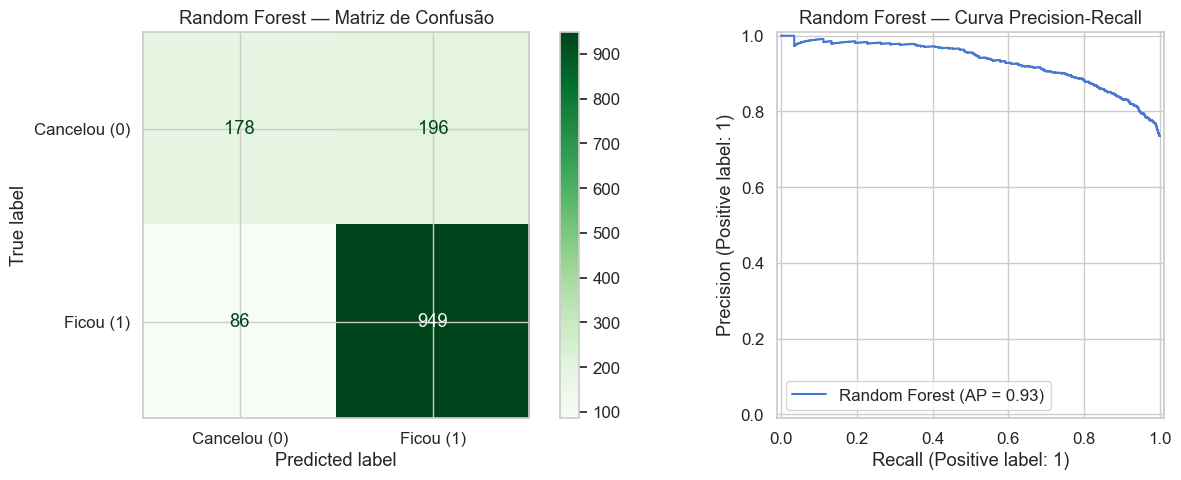

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["Cancelou (0)", "Ficou (1)"],
    cmap="Greens",
    ax=axes[0],
)
axes[0].set_title("Random Forest — Matriz de Confusão")

PrecisionRecallDisplay.from_predictions(
    y_test, y_prob_rf, pos_label=1, name="Random Forest", ax=axes[1]
)
axes[1].set_title("Random Forest — Curva Precision-Recall")

plt.tight_layout()
plt.show()

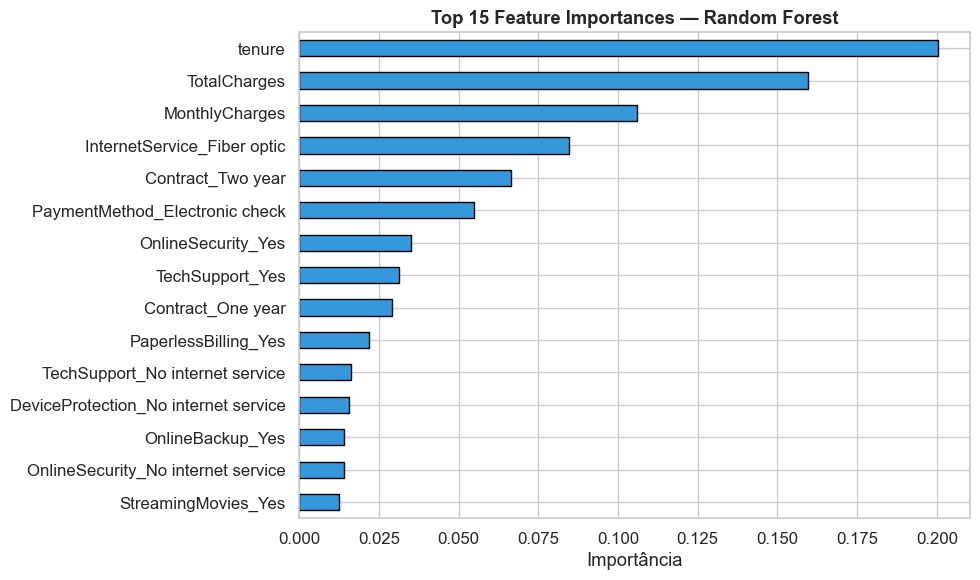

In [28]:
# Feature Importance — Random Forest
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top15 = importances.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 6))
top15.plot(kind="barh", ax=ax, color="#3498db", edgecolor="black")
ax.set_title("Top 15 Feature Importances — Random Forest", fontweight="bold")
ax.set_xlabel("Importância")
plt.tight_layout()
plt.show()

### 5.3 Comparação dos Modelos

Comparamos os baselines por **PR-AUC** (classe minoritária), **ROC-AUC** e **Brier Score**.
Os números da tabela são os **autoritativos** para o relatório final. O estágio causal usa o
melhor base learner deste comparativo (Random Forest), **calibrado** na etapa de Unit Selection.

In [29]:
from sklearn.metrics import roc_auc_score

# 5.7: tabela AUTORITATIVA de baseline (PR-AUC minoritária, ROC-AUC, Brier) —
# qualquer divergência com versões antigas do relatório deve ser alinhada a ESTES números.
comparison = pd.DataFrame(
    {
        "Modelo": ["Regressão Logística", "Random Forest"],
        "PR-AUC (minoritária)": [pr_auc_lr, pr_auc_rf],
        "ROC-AUC": [roc_auc_score(y_test, y_prob_lr), roc_auc_score(y_test, y_prob_rf)],
        "Brier Score": [brier_lr, brier_rf],
    }
).set_index("Modelo")

print("Comparação dos Modelos Baseline (números AUTORITATIVOS para o relatório):")
print("(PR-AUC e ROC-AUC: maior é melhor | Brier Score: menor é melhor)\n")
print(comparison.round(4).to_string())

melhor_pr = comparison["PR-AUC (minoritária)"].idxmax()
melhor_brier = comparison["Brier Score"].idxmin()
print(f"\nMelhor PR-AUC: {melhor_pr} | Melhor calibração (Brier): {melhor_brier}")
print(
    "Nota (consistência texto/tabela/código): neste dataset o Random Forest é marginalmente\n"
    "superior em PR-AUC e Brier. Por isso o estágio causal usa RF como base learner, calibrado\n"
    "via CalibratedClassifierCV (§14) — o que reduz ainda mais o Brier e alinha com o código."
)
comparison.round(4)


Comparação dos Modelos Baseline (números AUTORITATIVOS para o relatório):
(PR-AUC e ROC-AUC: maior é melhor | Brier Score: menor é melhor)

                     PR-AUC (minoritária)  ROC-AUC  Brier Score
Modelo                                                         
Regressão Logística                0.6096   0.8320       0.1415
Random Forest                      0.6420   0.8352       0.1388

Melhor PR-AUC: Random Forest | Melhor calibração (Brier): Random Forest
Nota (consistência texto/tabela/código): neste dataset o Random Forest é marginalmente
superior em PR-AUC e Brier. Por isso o estágio causal usa RF como base learner, calibrado
via CalibratedClassifierCV (§14) — o que reduz ainda mais o Brier e alinha com o código.


,PR-AUC (minoritária),ROC-AUC,Brier Score
Modelo,,,
Regressão Logística,0.6096,0.8320,0.1415
Random Forest,0.6420,0.8352,0.1388


---
## 6. DAG Causal

O grafo acíclico direcionado (DAG) abaixo representa a estrutura causal assumida para o problema de churn em telecomunicações, conforme a formulação do projeto.

### Estrutura do DAG

- **C → X**: As covariáveis do cliente (perfil demográfico, tipo de contrato, tempo de casa) influenciam quais serviços o cliente contrata — gerando **viés de seleção** nos dados observacionais.
- **C → Y**: As mesmas covariáveis afetam diretamente a probabilidade de retenção (ex: clientes com contratos longos têm menor churn).
- **X → Y**: Os tratamentos (TechSupport, StreamingTV, StreamingMovies) têm um **efeito causal direto** sobre a retenção — este é o efeito que queremos estimar.

### Premissa de Unconfoundedness

A premissa central é que, **condicionando nas covariáveis C observadas**, a atribuição do tratamento X é independente dos desfechos potenciais. Ou seja, não há confundidores não-observados. Essa premissa habilita o **Backdoor Adjustment**: ao controlar por C, podemos estimar $P(Y | do(X))$ a partir dos dados observacionais.

Na entrega final, utilizaremos Propensity Score Matching (PSM) ou IPW para operacionalizar esse ajuste, e os testes de refutação do DoWhy para avaliar a sensibilidade à violação dessa premissa.

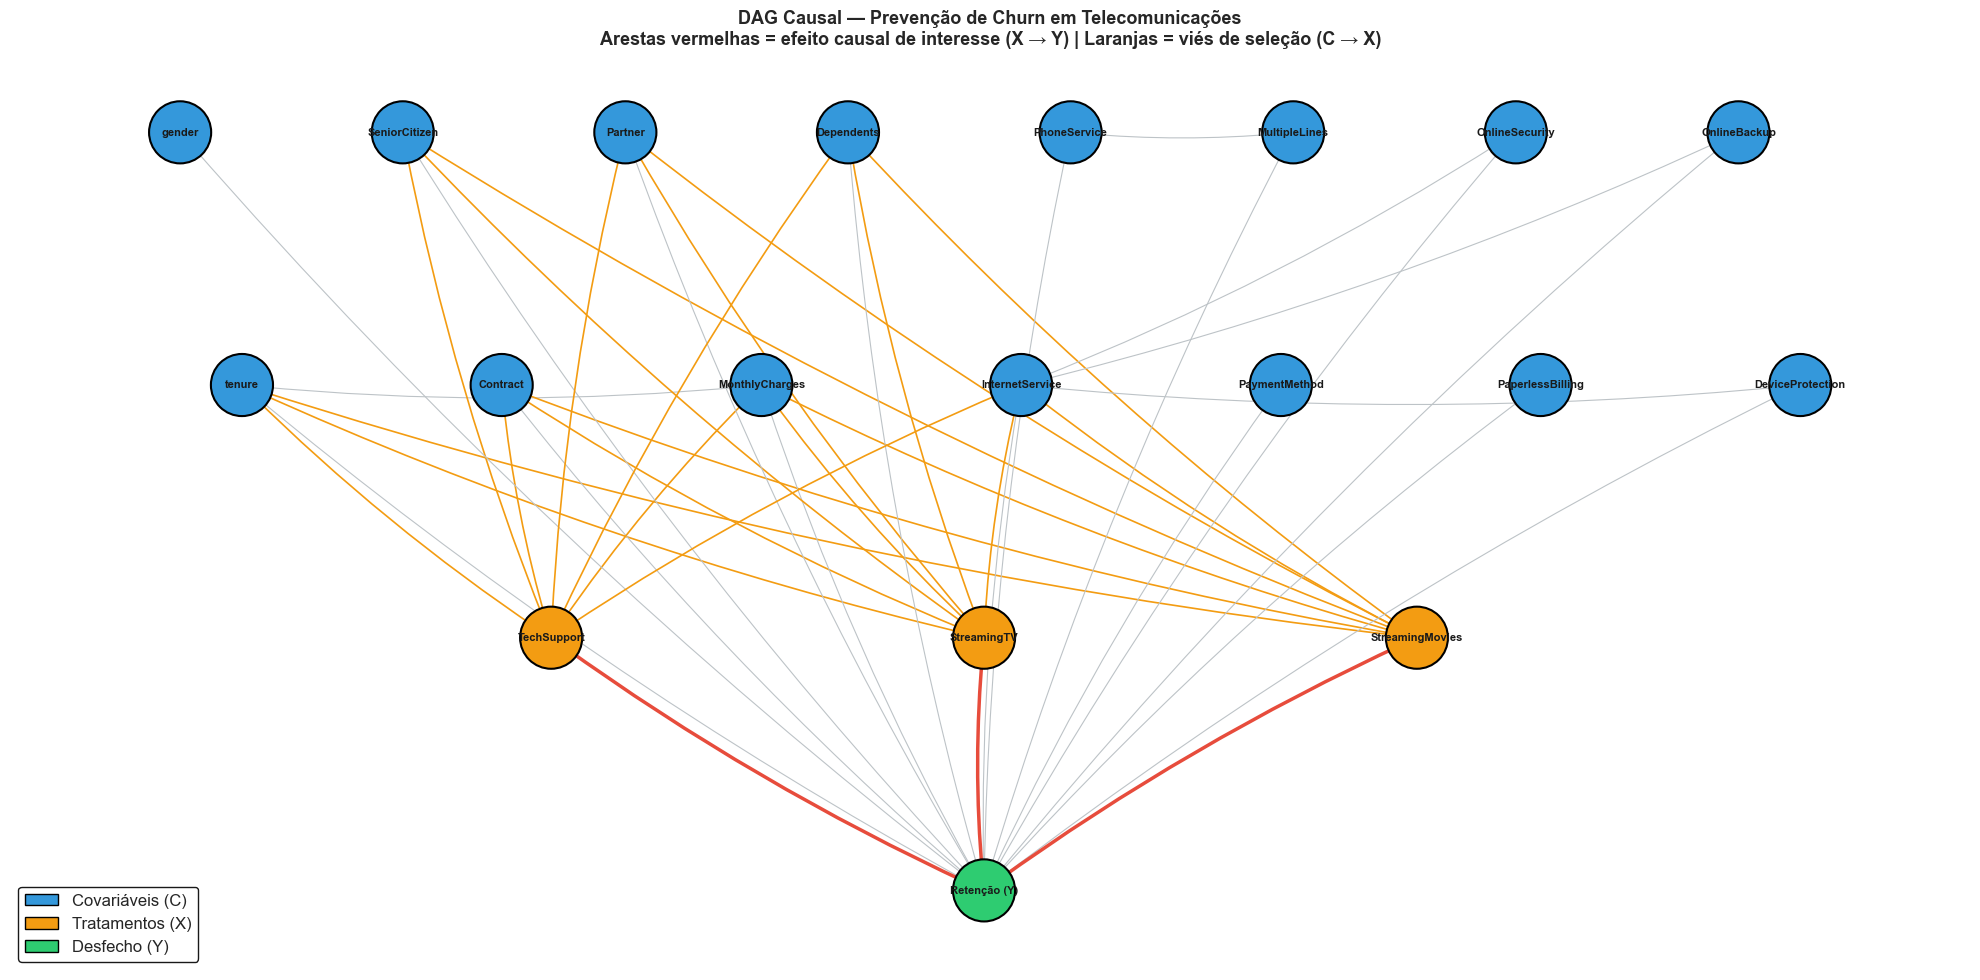

In [30]:
G = nx.DiGraph()

# -- Nós --
covariates_nodes = [
    "tenure",
    "Contract",
    "MonthlyCharges",
    "SeniorCitizen",
    "gender",
    "Partner",
    "Dependents",
    "InternetService",
    "PaymentMethod",
    "PaperlessBilling",
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
]
treatment_nodes = ["TechSupport", "StreamingTV", "StreamingMovies"]
outcome_node = "Retenção (Y)"

G.add_nodes_from(covariates_nodes)
G.add_nodes_from(treatment_nodes)
G.add_node(outcome_node)

# -- Arestas --
# C → X (covariáveis influenciam a adoção dos tratamentos)
confounders_to_treatment = [
    "tenure",
    "Contract",
    "MonthlyCharges",
    "SeniorCitizen",
    "InternetService",
    "Partner",
    "Dependents",
]
for c in confounders_to_treatment:
    for x in treatment_nodes:
        G.add_edge(c, x)

# C → Y (covariáveis influenciam a retenção diretamente)
for c in covariates_nodes:
    G.add_edge(c, outcome_node)

# X → Y (efeito causal dos tratamentos sobre a retenção)
for x in treatment_nodes:
    G.add_edge(x, outcome_node)

# Algumas relações entre covariáveis
G.add_edge("tenure", "TotalCharges" if "TotalCharges" in G.nodes else "MonthlyCharges")
G.add_edge("InternetService", "OnlineSecurity")
G.add_edge("InternetService", "OnlineBackup")
G.add_edge("InternetService", "DeviceProtection")
G.add_edge("PhoneService", "MultipleLines")

# -- Layout --
pos = {}

# Covariáveis em duas fileiras no topo
top_row = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
]
mid_row = [
    "tenure",
    "Contract",
    "MonthlyCharges",
    "InternetService",
    "PaymentMethod",
    "PaperlessBilling",
    "DeviceProtection",
]

for i, node in enumerate(top_row):
    pos[node] = (i * 1.8, 3)
for i, node in enumerate(mid_row):
    pos[node] = (i * 2.1 + 0.5, 1.5)

# Tratamentos no meio
for i, node in enumerate(treatment_nodes):
    pos[node] = (3 + i * 3.5, 0)

# Desfecho embaixo
pos[outcome_node] = (6.5, -1.5)

# -- Cores por tipo de nó --
node_colors = []
for node in G.nodes():
    if node in treatment_nodes:
        node_colors.append("#f39c12")
    elif node == outcome_node:
        node_colors.append("#2ecc71")
    else:
        node_colors.append("#3498db")

# -- Desenhar --
fig, ax = plt.subplots(figsize=(20, 10))

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=2000,
    edgecolors="black",
    linewidths=1.5,
    ax=ax,
)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold", ax=ax)

# Arestas C→Y em cinza claro, X→Y em vermelho forte, C→X em laranja
edge_colors = []
edge_widths = []
for u, v in G.edges():
    if u in treatment_nodes and v == outcome_node:
        edge_colors.append("#e74c3c")
        edge_widths.append(2.5)
    elif v in treatment_nodes:
        edge_colors.append("#f39c12")
        edge_widths.append(1.2)
    else:
        edge_colors.append("#bdc3c7")
        edge_widths.append(0.8)

nx.draw_networkx_edges(
    G,
    pos,
    edge_color=edge_colors,
    width=edge_widths,
    arrows=True,
    arrowsize=15,
    arrowstyle="->",
    connectionstyle="arc3,rad=0.05",
    ax=ax,
)

# Legenda
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="#3498db", edgecolor="black", label="Covariáveis (C)"),
    Patch(facecolor="#f39c12", edgecolor="black", label="Tratamentos (X)"),
    Patch(facecolor="#2ecc71", edgecolor="black", label="Desfecho (Y)"),
]
ax.legend(
    handles=legend_elements,
    loc="lower left",
    fontsize=12,
    framealpha=0.9,
    edgecolor="black",
)

ax.set_title(
    "DAG Causal — Prevenção de Churn em Telecomunicações\n"
    "Arestas vermelhas = efeito causal de interesse (X → Y) | "
    "Laranjas = viés de seleção (C → X)",
    fontsize=13,
    fontweight="bold",
)
ax.axis("off")
plt.tight_layout()
plt.show()

### Interpretação do DAG

As arestas **vermelhas** (X → Y) representam o efeito causal que queremos isolar na entrega final: o impacto de oferecer TechSupport, StreamingTV ou StreamingMovies sobre a retenção.

As arestas **laranjas** (C → X) representam o **viés de seleção**: clientes com certas características (ex: maior tenure, contrato longo) têm maior probabilidade de já possuir esses serviços. Se não controlarmos por C, a associação observacional entre X e Y mistura o efeito causal com esse viés.

O critério **Backdoor** nos diz que, ao condicionar em C, bloqueamos todos os caminhos espúrios entre X e Y, permitindo identificar o efeito causal $P(Y | do(X))$ a partir dos dados observacionais.

---
## 7. Validação da Premissa de Positividade (Propensity Score Overlap)

Para garantir que a inferência causal será possível na etapa final, precisamos provar a premissa de **Positividade (Overlap)**. Vamos calcular a probabilidade de um cliente receber o tratamento principal (`TechSupport`) dadas as suas covariáveis (Propensity Score) e verificar se as distribuições dos grupos Tratado e Controle se sobrepõem.

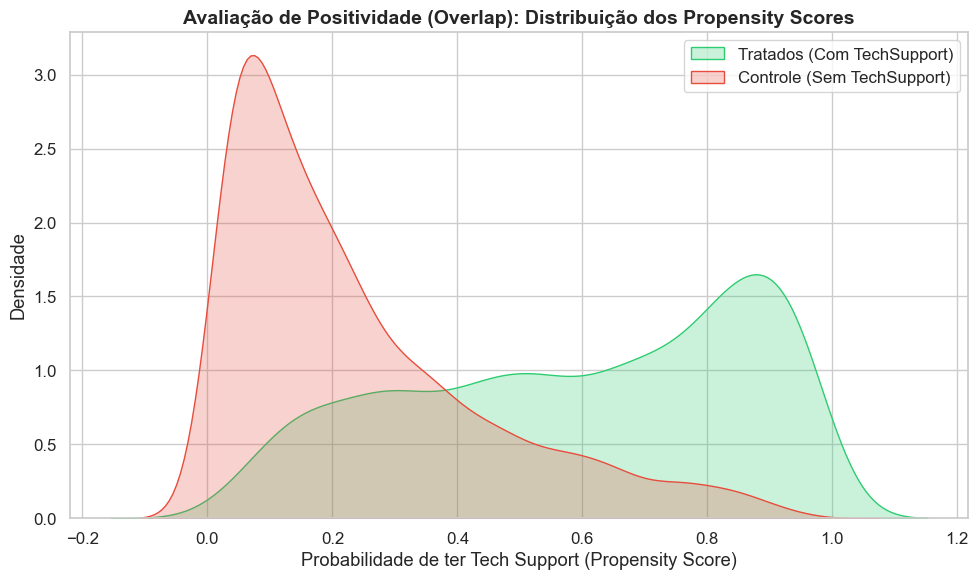

In [31]:
# 1. Preparar os dados para o Propensity Score Model
# Alvo: Ter TechSupport (Ignorando 'No internet service' para esta validação binária)
df_ps = df[df["TechSupport"] != "No internet service"].copy()
df_ps["Treat_TechSupport"] = (df_ps["TechSupport"] == "Yes").astype(int)

# Covariáveis (C) - Tudo exceto Tratamentos e Target
X_ps = df_ps[COVARIATES]
X_ps = pd.get_dummies(X_ps, drop_first=True)

# 2. Treinar um modelo Logístico simples para prever o Tratamento
# 4.4: padronizar as features evita o ConvergenceWarning e estabiliza os PS
ps_scaler = StandardScaler()
X_ps_scaled = ps_scaler.fit_transform(X_ps.astype(float))
ps_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
ps_model.fit(X_ps_scaled, df_ps["Treat_TechSupport"])

# 3. Extrair as probabilidades (Propensity Scores)
df_ps["Propensity_Score"] = ps_model.predict_proba(X_ps_scaled)[:, 1]

# 4. Plotar o Gráfico de Overlap
fig, ax = plt.subplots(figsize=(10, 6))

sns.kdeplot(
    data=df_ps[df_ps["Treat_TechSupport"] == 1],
    x="Propensity_Score",
    fill=True,
    color="#2ecc71",
    label="Tratados (Com TechSupport)",
    ax=ax,
)
sns.kdeplot(
    data=df_ps[df_ps["Treat_TechSupport"] == 0],
    x="Propensity_Score",
    fill=True,
    color="#e74c3c",
    label="Controle (Sem TechSupport)",
    ax=ax,
)

ax.set_title(
    "Avaliação de Positividade (Overlap): Distribuição dos Propensity Scores",
    fontsize=14,
    fontweight="bold",
)
ax.set_xlabel("Probabilidade de ter Tech Support (Propensity Score)")
ax.set_ylabel("Densidade")
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. Estimação Causal Inicial (ATE via IPW)

Nesta seção, realizaremos a nossa primeira estimação causal. O objetivo é calcular o Efeito Médio do Tratamento (ATE) na base, isolando matematicamente o viés de seleção (efeito das covariáveis $C$) que identificamos na etapa de exploração.

Para isso, utilizaremos a técnica de **Ponderação pelo Inverso da Probabilidade (IPW - Inverse Probability Weighting)**. O IPW utiliza os *Propensity Scores* $e(C_i) = P(X=1 \mid C_i)$ calculados na seção anterior para reponderar as instâncias do dataset. Essa técnica atribui pesos maiores a observações raras (ex: clientes com baixa propensão que receberam o tratamento) e pesos menores a observações comuns, criando uma pseudo-população onde o tratamento $X$ se torna independente das covariáveis $C$ (simulando um ensaio clínico randomizado).

A fórmula do estimador causal IPW para o ATE é definida por:

$$\hat{ATE}_{IPW} = \frac{1}{N} \sum_{i=1}^{N} \left( \frac{X_i Y_i}{e(C_i)} - \frac{(1 - X_i) Y_i}{1 - e(C_i)} \right)$$

Onde:
* $X_i$: Variável indicadora de tratamento (1 se tem `TechSupport`, 0 caso contrário).
* $Y_i$: Desfecho de retenção (1 se ficou, 0 se cancelou).
* $e(C_i)$: Probabilidade prevista de receber o tratamento dadas as covariáveis (Propensity Score).

O bloco de código abaixo aplica essa formulação diretamente sobre os dados para contrastar o Efeito Observacional Ingênuo (enviesado) com o verdadeiro Efeito Causal Médio.

In [32]:
# ==========================================
# 8. Estimação Causal Inicial (ATE via IPW)
# ==========================================
# Vamos calcular o Efeito Médio do Tratamento usando Inverse Probability Weighting (IPW)

# 1. Recuperamos a variável alvo (Y = Retenção) para esta base filtrada
df_ps["Y_Retencao"] = df.loc[df_ps.index, "Y"]

# 2. Evitar divisão por zero ou pesos infinitos (Trimming/Clipping dos Propensity Scores)
# Limitamos as probabilidades entre 0.05 e 0.95
ps_clipped = np.clip(df_ps["Propensity_Score"], 0.05, 0.95)

# 3. Cálculo dos Pesos IPW
# Peso para os Tratados: 1 / PS
# Peso para o Controle: 1 / (1 - PS)
df_ps["IPW_Weight"] = np.where(
    df_ps["Treat_TechSupport"] == 1, 1 / ps_clipped, 1 / (1 - ps_clipped)
)

# 4. Cálculo do Efeito Ingênuo (Observacional Bruto)
media_tratados_ingenuo = df_ps[df_ps["Treat_TechSupport"] == 1]["Y_Retencao"].mean()
media_controle_ingenuo = df_ps[df_ps["Treat_TechSupport"] == 0]["Y_Retencao"].mean()
efeito_ingenuo = media_tratados_ingenuo - media_controle_ingenuo

# 5. Cálculo do Efeito Causal (ATE via IPW)
media_tratados_causal = np.average(
    df_ps[df_ps["Treat_TechSupport"] == 1]["Y_Retencao"],
    weights=df_ps[df_ps["Treat_TechSupport"] == 1]["IPW_Weight"],
)
media_controle_causal = np.average(
    df_ps[df_ps["Treat_TechSupport"] == 0]["Y_Retencao"],
    weights=df_ps[df_ps["Treat_TechSupport"] == 0]["IPW_Weight"],
)
ate_ipw = media_tratados_causal - media_controle_causal

# 6. Exibir os resultados
print("=== RESULTADOS DA ESTIMAÇÃO DO ATE ===")
print(f"Taxa de Retenção (Sem Suporte - Controle): {media_controle_ingenuo:.2%}")
print(f"Taxa de Retenção (Com Suporte - Tratado):  {media_tratados_ingenuo:.2%}")
print(
    f"-> EFEITO INGÊNUO (Viés incluído): Aumenta a retenção em {efeito_ingenuo*100:.2f} pontos percentuais.\n"
)

print("Após o Ajuste Causal (IPW):")
print(
    f"Retenção Contrafactual (Se todos tivessem Controle): {media_controle_causal:.2%}"
)
print(
    f"Retenção Contrafactual (Se todos tivessem Suporte):  {media_tratados_causal:.2%}"
)
print(
    f"-> EFEITO CAUSAL MÉDIO (ATE): Aumenta a retenção em {ate_ipw*100:.2f} pontos percentuais.\n"
)

vies_removido = efeito_ingenuo - ate_ipw
print(
    f"CONCLUSÃO: O Machine Learning tradicional superestimou o poder do TechSupport em {vies_removido*100:.2f} pontos percentuais devido ao viés de lealdade (tenure/contrato)."
)

=== RESULTADOS DA ESTIMAÇÃO DO ATE ===
Taxa de Retenção (Sem Suporte - Controle): 58.36%
Taxa de Retenção (Com Suporte - Tratado):  84.83%
-> EFEITO INGÊNUO (Viés incluído): Aumenta a retenção em 26.47 pontos percentuais.

Após o Ajuste Causal (IPW):
Retenção Contrafactual (Se todos tivessem Controle): 65.94%
Retenção Contrafactual (Se todos tivessem Suporte):  76.66%
-> EFEITO CAUSAL MÉDIO (ATE): Aumenta a retenção em 10.72 pontos percentuais.

CONCLUSÃO: O Machine Learning tradicional superestimou o poder do TechSupport em 15.75 pontos percentuais devido ao viés de lealdade (tenure/contrato).


---
## 9. Descoberta Causal e Refinamento do DAG

Nas seções anteriores estimamos o ATE usando o DAG construído via conhecimento de domínio. Nesta etapa, vamos **testar empiricamente** essa estrutura e refiná-la usando algoritmos de descoberta causal sobre os dados.

O processo segue 5 fases:

1. **Pré-processamento causal**: label encoding + escala (one-hot atrapalha descoberta).
2. **Background Knowledge**: tiers temporais + arestas proibidas.
3. **Discovery**: PC (constraint), GES (score), FCI (variáveis latentes).
4. **Scoring Bayesiano**: comparar DAGs via BIC/BDeu em `pgmpy`.
5. **Validação com `DoWhy`**: identificação por backdoor + refutações.

### 9.1 Pré-processamento para Causal Discovery

Algoritmos de estrutura exigem entradas numéricas, sem nulos, e **não** podem receber one-hot encoding (geraria dependência determinística entre dummies da mesma variável). Por isso usamos label encoding aqui — diferente do pré-processamento de ML da seção 4.


In [33]:
%pip install -q causal-learn pgmpy dowhy pydot

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
from sklearn.preprocessing import LabelEncoder

# Cópia do df limpo (já sem nulos, com Y construído)
df_causal = df.copy()

# Label-encode todas as colunas categóricas (string)
label_encoders = {}
for col in df_causal.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df_causal[col] = le.fit_transform(df_causal[col].astype(str))
    label_encoders[col] = le

# Padronizar contínuas
continuous_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
scaler_causal = StandardScaler()
df_causal[continuous_cols] = scaler_causal.fit_transform(df_causal[continuous_cols])

# Matriz numérica para causal-learn
data_causal = df_causal.values.astype(float)
node_names = df_causal.columns.tolist()

print(f"Shape para causal discovery: {data_causal.shape}")
print(f"Nós ({len(node_names)}): {node_names}")
df_causal.head()

Shape para causal discovery: (7043, 20)
Nós (20): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Y']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Y
0,0,0,1,0,-1.277445,0,1,0,0,2,0,0,0,0,0,1,2,-1.160323,-0.992611,1
1,1,0,0,0,0.066327,1,0,0,2,0,2,0,0,0,1,0,3,-0.259629,-0.172165,1
2,1,0,0,0,-1.236724,1,0,0,2,2,0,0,0,0,0,1,3,-0.362660,-0.958066,0
3,1,0,0,0,0.514251,0,1,0,2,0,2,2,0,0,1,0,0,-0.746535,-0.193672,1
4,0,0,0,0,-1.236724,1,0,1,0,0,0,0,0,0,0,1,2,0.197365,-0.938874,0


In [35]:
# 9.1.b — Discretização única para descoberta e scoring (4.1 / 4.2)
# Algoritmos baseados em teste qui-quadrado (PC/FCI) e score BDeu (GES/pgmpy) exigem dados
# DISCRETOS. Construímos UMA versão consistente — categóricas em códigos + contínuas em
# quintis — reaproveitada por todas as etapas (torna os scores BIC/BDeu comparáveis).
df_disc = df.copy()
for col in df_disc.select_dtypes(include="object").columns:
    df_disc[col] = df_disc[col].astype("category").cat.codes
for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    df_disc[col] = pd.qcut(df_disc[col], q=5, labels=False, duplicates="drop").astype(
        int
    )

df_disc = df_disc[node_names]  # mesma ordem de colunas que node_names
data_disc = df_disc.values.astype(int)
print(
    f"Dados discretos p/ descoberta e scoring: {data_disc.shape} | "
    f"níveis máx por variável: {int(data_disc.max()) + 1}"
)

Dados discretos p/ descoberta e scoring: (7043, 20) | níveis máx por variável: 5


### 9.2 Background Knowledge (Tiering Temporal)

Definimos uma hierarquia temporal entre as variáveis. Nenhuma aresta pode ir de um tier posterior para um anterior — por exemplo, `Y` não pode causar `gender`, e `TechSupport` não pode causar `SeniorCitizen`.

| Tier | Variáveis | Justificativa |
|------|-----------|---------------|
| 1 — Demografia imutável | `gender`, `SeniorCitizen` | Determinadas antes da relação com a operadora |
| 2 — Setup de conta | `Contract`, `Dependents`, `Partner` | Definidos no início do contrato |
| 3 — Uso e serviços | `tenure`, `MonthlyCharges`, `TotalCharges`, `TechSupport`, `StreamingTV`, etc. | Evoluem durante a relação |
| 4 — Desfecho | `Y` (Retenção) | Resultado observado |


In [36]:
# Definir tiers conforme o action plan
TIER_1 = ["gender", "SeniorCitizen"]
TIER_2 = ["Contract", "Dependents", "Partner"]
TIER_3 = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "PaperlessBilling",
    "PaymentMethod",
]
TIER_4 = ["Y"]

tiers = {1: TIER_1, 2: TIER_2, 3: TIER_3, 4: TIER_4}
tier_of = {v: t for t, vars in tiers.items() for v in vars}

print("Tiers:")
for t, vars in tiers.items():
    print(f"  Tier {t}: {vars}")

# Arestas proibidas: qualquer aresta que viole a ordem temporal
node_idx = {n: i for i, n in enumerate(node_names)}
forbidden_pairs = []  # lista de pares (src_name, tgt_name)
for src in node_names:
    for tgt in node_names:
        if src == tgt:
            continue
        if tier_of.get(src, 0) > tier_of.get(tgt, 0):
            forbidden_pairs.append((src, tgt))

print(f"\nTotal de arestas proibidas (backward in time): {len(forbidden_pairs)}")
print(f"Exemplos: {forbidden_pairs[:5]}")

Tiers:
  Tier 1: ['gender', 'SeniorCitizen']
  Tier 2: ['Contract', 'Dependents', 'Partner']
  Tier 3: ['tenure', 'MonthlyCharges', 'TotalCharges', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'PaymentMethod']
  Tier 4: ['Y']

Total de arestas proibidas (backward in time): 95
Exemplos: [('Partner', 'gender'), ('Partner', 'SeniorCitizen'), ('Dependents', 'gender'), ('Dependents', 'SeniorCitizen'), ('tenure', 'gender')]


### 9.3 Descoberta — PC Algorithm (Constraint-Based, Fisher-Z)

O PC parte de um grafo completo e remove arestas usando testes de independência condicional. Usamos Fisher-Z (apropriado quando assumimos relações lineares/gaussianas; razoável aqui após o encoding numérico). A `BackgroundKnowledge` injeta as restrições do tier.


In [37]:
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import (
    chisq,
)  # 4.1: dados discretos -> qui-quadrado (não Fisher-Z)
from causallearn.graph.GraphNode import GraphNode
from causallearn.graph.Endpoint import Endpoint

# Tentar importar BackgroundKnowledge (caminho varia entre versões)
try:
    from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
except ImportError:
    from causallearn.utils.BackgroundKnowledge import BackgroundKnowledge

cl_nodes = [GraphNode(n) for n in node_names]
cl_node_map = {n: cl_nodes[i] for i, n in enumerate(node_names)}

bk = BackgroundKnowledge()
# Arestas proibidas: ordem temporal dos tiers
for src, tgt in forbidden_pairs:
    bk.add_forbidden_by_node(cl_node_map[src], cl_node_map[tgt])

# 4.3: arestas REQUERIDAS — tenure e Contract são confounders fortes (§6) e devem influenciar
# tanto os tratamentos quanto o desfecho (background knowledge de domínio).
required_pairs = []
for cvar in ["tenure", "Contract"]:
    required_pairs.append((cvar, "Y"))
    for x in TREATMENTS:
        required_pairs.append((cvar, x))
for src, tgt in required_pairs:
    bk.add_required_by_node(cl_node_map[src], cl_node_map[tgt])

print(
    f"Background knowledge: {len(forbidden_pairs)} proibidas + {len(required_pairs)} requeridas."
)

cg_pc = pc(
    data_disc,  # 4.1: dados discretizados
    alpha=0.05,
    indep_test=chisq,
    background_knowledge=bk,
    node_names=node_names,
    show_progress=False,
)
print("PC concluído (chisq, discreto, com tenure/Contract requeridos).")

Background knowledge: 95 proibidas + 8 requeridas.


PC concluído (chisq, discreto, com tenure/Contract requeridos).


In [38]:
def extract_edges_from_general_graph(G, names):
    """Extrai arestas direcionadas e não-direcionadas de um GeneralGraph (causal-learn)."""
    directed = []
    undirected = []
    nodes = G.get_nodes()
    n = len(nodes)
    for i in range(n):
        for j in range(i + 1, n):
            e = G.get_edge(nodes[i], nodes[j])
            if e is None:
                continue
            ep1, ep2 = e.get_endpoint1(), e.get_endpoint2()
            if ep1 == Endpoint.TAIL and ep2 == Endpoint.ARROW:
                directed.append((names[i], names[j]))
            elif ep1 == Endpoint.ARROW and ep2 == Endpoint.TAIL:
                directed.append((names[j], names[i]))
            else:
                undirected.append((names[i], names[j]))
    return directed, undirected


pc_directed, pc_undirected = extract_edges_from_general_graph(cg_pc.G, node_names)
print(f"PC — Arestas direcionadas: {len(pc_directed)}")
print(f"PC — Arestas não-direcionadas (Markov equivalence): {len(pc_undirected)}")
print("\nArestas direcionadas relevantes (envolvendo X ou Y):")
for s, t in pc_directed:
    if s in TREATMENTS + [TARGET] or t in TREATMENTS + [TARGET]:
        print(f"  {s} -> {t}")

PC — Arestas direcionadas: 39
PC — Arestas não-direcionadas (Markov equivalence): 0

Arestas direcionadas relevantes (envolvendo X ou Y):
  SeniorCitizen -> TechSupport
  InternetService -> TechSupport
  InternetService -> StreamingTV
  InternetService -> Y
  OnlineSecurity -> Y
  DeviceProtection -> StreamingTV
  DeviceProtection -> StreamingMovies
  TechSupport -> Contract
  TechSupport -> MonthlyCharges
  StreamingTV -> StreamingMovies
  StreamingTV -> PaymentMethod
  StreamingTV -> MonthlyCharges
  StreamingTV -> TotalCharges
  StreamingMovies -> MonthlyCharges
  StreamingMovies -> TotalCharges
  Contract -> Y
  PaymentMethod -> Y


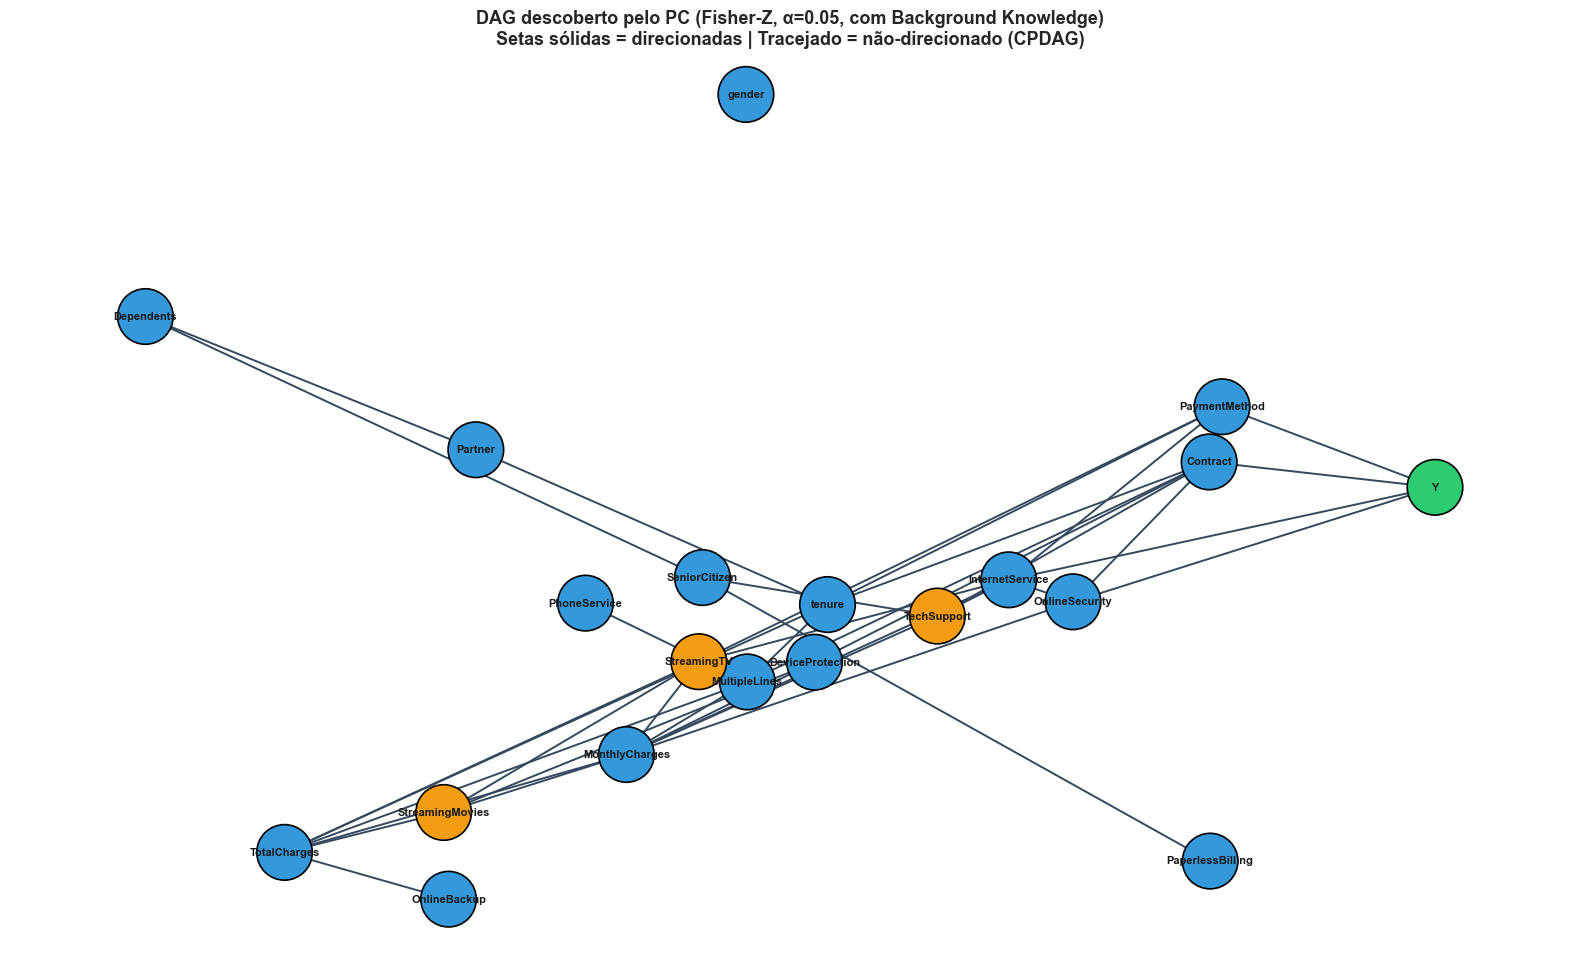

In [39]:
def plot_dag_from_edges(directed, undirected, title, highlight_nodes=None):
    G = nx.DiGraph()
    G.add_nodes_from(node_names)
    G.add_edges_from(directed)
    # undirected: representar com duas arestas (apenas para visualização)
    UG_edges = undirected

    highlight_nodes = highlight_nodes or {}
    pos = nx.spring_layout(G, k=1.5, seed=RANDOM_STATE, iterations=200)

    fig, ax = plt.subplots(figsize=(16, 10))
    colors = []
    for n in G.nodes():
        if n in TREATMENTS:
            colors.append("#f39c12")
        elif n == TARGET:
            colors.append("#2ecc71")
        else:
            colors.append("#3498db")
    nx.draw_networkx_nodes(
        G,
        pos,
        node_color=colors,
        node_size=1600,
        edgecolors="black",
        linewidths=1.2,
        ax=ax,
    )
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold", ax=ax)
    nx.draw_networkx_edges(
        G,
        pos,
        edge_color="#34495e",
        width=1.4,
        arrows=True,
        arrowsize=14,
        arrowstyle="->",
        ax=ax,
    )
    if UG_edges:
        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=UG_edges,
            edge_color="#95a5a6",
            style="dashed",
            width=1.0,
            arrows=False,
            ax=ax,
        )
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


plot_dag_from_edges(
    pc_directed,
    pc_undirected,
    "DAG descoberto pelo PC (Fisher-Z, α=0.05, com Background Knowledge)\n"
    "Setas sólidas = direcionadas | Tracejado = não-direcionado (CPDAG)",
)

### 9.4 Descoberta — GES (Score-Based, BIC)

GES (Greedy Equivalence Search) realiza uma busca local que adiciona/remove arestas para maximizar a verossimilhança penalizada (BIC). Retorna a classe de equivalência de Markov (CPDAG).


GES BDeu score: -85030.96887827155
GES — Arestas direcionadas: 31
GES — Arestas não-direcionadas: 12


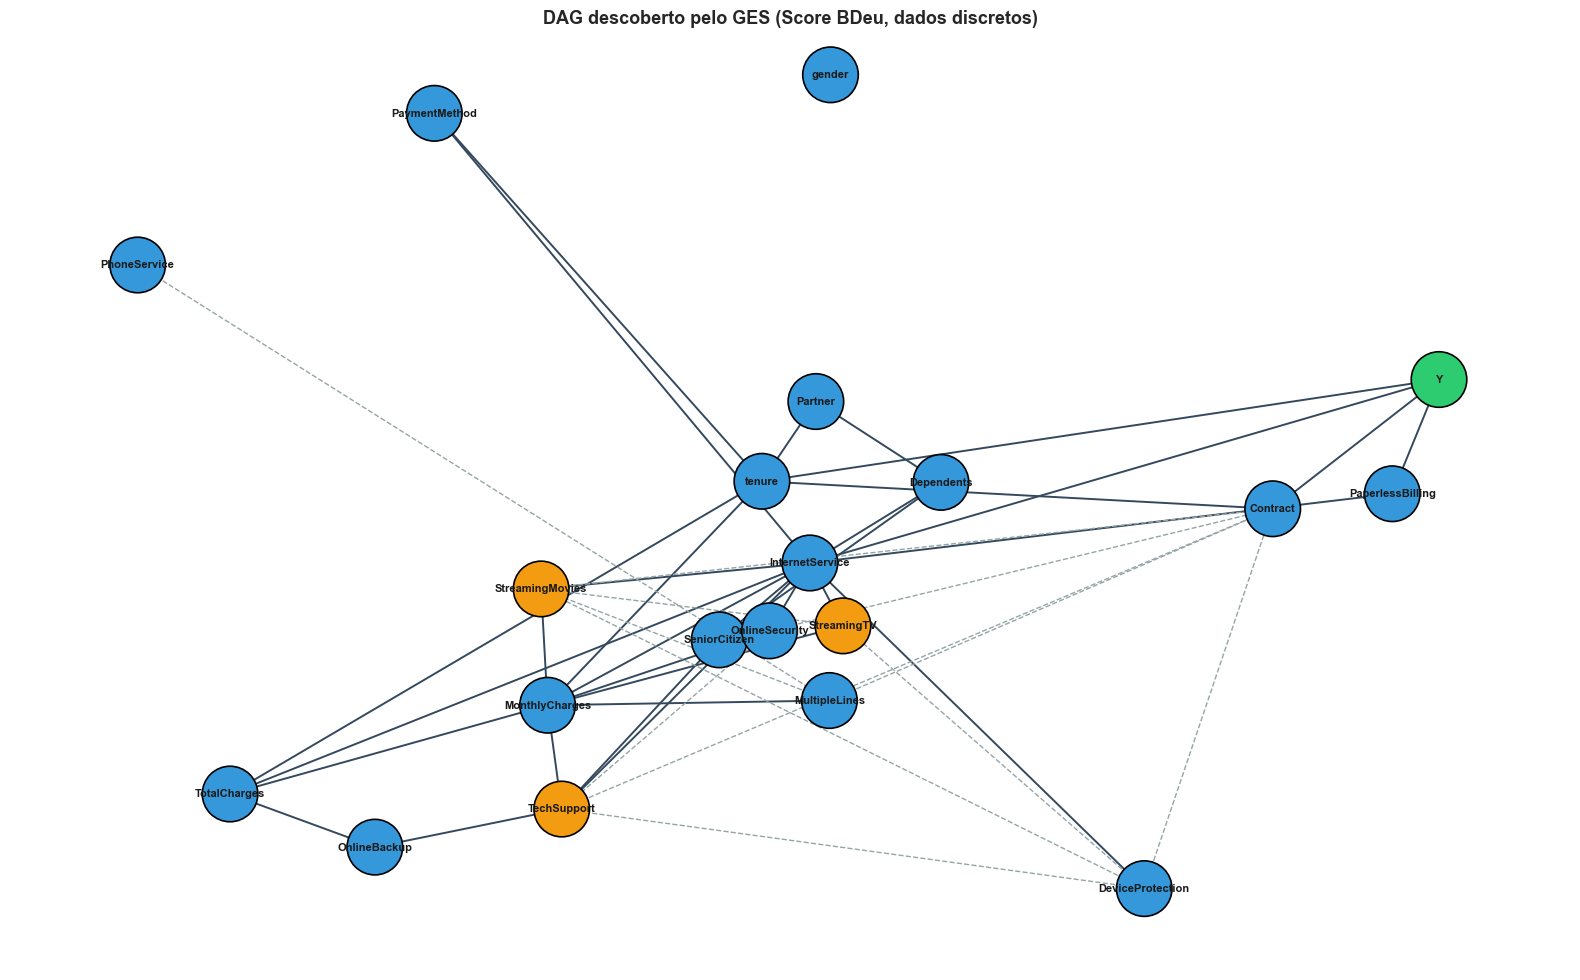

In [40]:
from causallearn.search.ScoreBased.GES import ges

# 4.1: dados discretos -> score BDeu (BIC gaussiano não é apropriado para variáveis discretas)
ges_result = ges(data_disc, score_func="local_score_BDeu")
G_ges = ges_result["G"]
print(f"GES BDeu score: {ges_result.get('score', 'n/d')}")

ges_directed, ges_undirected = extract_edges_from_general_graph(G_ges, node_names)
print(f"GES — Arestas direcionadas: {len(ges_directed)}")
print(f"GES — Arestas não-direcionadas: {len(ges_undirected)}")

plot_dag_from_edges(
    ges_directed,
    ges_undirected,
    "DAG descoberto pelo GES (Score BDeu, dados discretos)",
)

### 9.5 Descoberta — FCI (Latent Confounders)

FCI relaxa a suposição de causal sufficiency do PC — ele aceita que possa haver confundidores não observados. As arestas resultantes podem ser:

- `A -> B`: causalidade direta
- `A o-> B`: incerteza sobre a origem
- `A <-> B`: confundidor latente entre A e B

A presença de arestas bidirecionadas seria um alerta para violação de unconfoundedness.


In [41]:
from causallearn.search.ConstraintBased.FCI import fci
from causallearn.utils.cit import chisq  # 4.1: qui-quadrado para dados discretos

# 4.1: FCI sobre dados discretos, com qui-quadrado
g_fci, edges_fci = fci(
    data_disc,
    independence_test_method=chisq,
    alpha=0.05,
    background_knowledge=bk,
    verbose=False,
    show_progress=False,
)

# FCI usa endpoints adicionais (CIRCLE). Vamos contabilizar tipos:
from collections import Counter


def ep_name(ep):
    """Endpoint -> string hashable (compatível entre versões do causal-learn)."""
    for attr in ("name", "value"):
        if hasattr(ep, attr):
            v = getattr(ep, attr)
            if isinstance(v, (str, int)):
                return str(v)
    return str(ep)


TAIL = ep_name(Endpoint.TAIL)
ARROW = ep_name(Endpoint.ARROW)

edge_types = Counter()
fci_directed = []
fci_bidirected = []
fci_other = []
nodes_fci = g_fci.get_nodes()
n = len(nodes_fci)
for i in range(n):
    for j in range(i + 1, n):
        e = g_fci.get_edge(nodes_fci[i], nodes_fci[j])
        if e is None:
            continue
        ep1, ep2 = ep_name(e.get_endpoint1()), ep_name(e.get_endpoint2())
        edge_types[(ep1, ep2)] += 1
        if ep1 == TAIL and ep2 == ARROW:
            fci_directed.append((node_names[i], node_names[j]))
        elif ep1 == ARROW and ep2 == TAIL:
            fci_directed.append((node_names[j], node_names[i]))
        elif ep1 == ARROW and ep2 == ARROW:
            fci_bidirected.append((node_names[i], node_names[j]))
        else:
            fci_other.append((node_names[i], node_names[j]))

print("FCI — Tipos de arestas:")
for k, v in edge_types.items():
    print(f"  {k}: {v}")
print(
    f"\nDirected: {len(fci_directed)} | Bidirected (latente!): {len(fci_bidirected)} | Outras: {len(fci_other)}"
)
if fci_bidirected:
    print("\nALERTA: FCI detectou possíveis confundidores latentes:")
    for s, t in fci_bidirected:
        print(f"  {s} <-> {t}")
else:
    print(
        "\nFCI não identificou confundidores latentes — premissa de unconfoundedness é plausível."
    )

Starting BK Orientation.
Finishing BK Orientation.


Starting BK Orientation.
Finishing BK Orientation.
X17 --> X5
X5 --> X19
X7 --> X18
X19 --> X7
X8 --> X9
X12 --> X8
X8 --> X18
X8 --> X20
X9 --> X18
X15 --> X12
X12 --> X18
X13 --> X14
X19 --> X13
X19 --> X14
X20 --> X15
X19 --> X18
FCI — Tipos de arestas:
  ('ARROW', 'ARROW'): 8
  ('CIRCLE', 'ARROW'): 5
  ('TAIL', 'ARROW'): 17

Directed: 17 | Bidirected (latente!): 8 | Outras: 5

ALERTA: FCI detectou possíveis confundidores latentes:
  SeniorCitizen <-> Dependents
  tenure <-> Contract
  MultipleLines <-> Contract
  OnlineSecurity <-> Contract
  StreamingTV <-> PaymentMethod
  StreamingTV <-> MonthlyCharges
  StreamingMovies <-> MonthlyCharges
  Contract <-> PaymentMethod


### 9.6 Edges Estáveis (Consenso entre algoritmos)

Arestas direcionadas que aparecem em pelo menos 2 dos 3 algoritmos são consideradas estáveis e formam a base do DAG refinado.


In [42]:
set_pc = set(pc_directed)
set_ges = set(ges_directed)
set_fci = set(fci_directed)

all_edges = set_pc | set_ges | set_fci

consensus_rows = []
for e in sorted(all_edges):
    in_pc = e in set_pc
    in_ges = e in set_ges
    in_fci = e in set_fci
    n_alg = int(in_pc) + int(in_ges) + int(in_fci)
    consensus_rows.append(
        {
            "src": e[0],
            "tgt": e[1],
            "PC": in_pc,
            "GES": in_ges,
            "FCI": in_fci,
            "n_alg": n_alg,
        }
    )

consensus_df = (
    pd.DataFrame(consensus_rows)
    .sort_values(["n_alg", "src", "tgt"], ascending=[False, True, True])
    .reset_index(drop=True)
)

stable_edges = [(r.src, r.tgt) for r in consensus_df.itertuples() if r.n_alg >= 2]
print(f"Total de arestas únicas: {len(all_edges)}")
print(f"Arestas estáveis (>=2 algoritmos): {len(stable_edges)}")
print("\nTop arestas por consenso:")
consensus_df.head(20)

Total de arestas únicas: 49
Arestas estáveis (>=2 algoritmos): 27

Top arestas por consenso:


,src,tgt,PC,GES,FCI,n_alg
0,Contract,Y,True,True,True,3
1,InternetService,MonthlyCharges,True,True,True,3
2,InternetService,OnlineSecurity,True,True,True,3
3,InternetService,TechSupport,True,True,True,3
4,InternetService,Y,True,True,True,3
5,MonthlyCharges,TotalCharges,True,True,True,3
6,MultipleLines,MonthlyCharges,True,True,True,3
7,OnlineSecurity,MonthlyCharges,True,True,True,3
8,TechSupport,MonthlyCharges,True,True,True,3
9,tenure,PaymentMethod,True,True,True,3


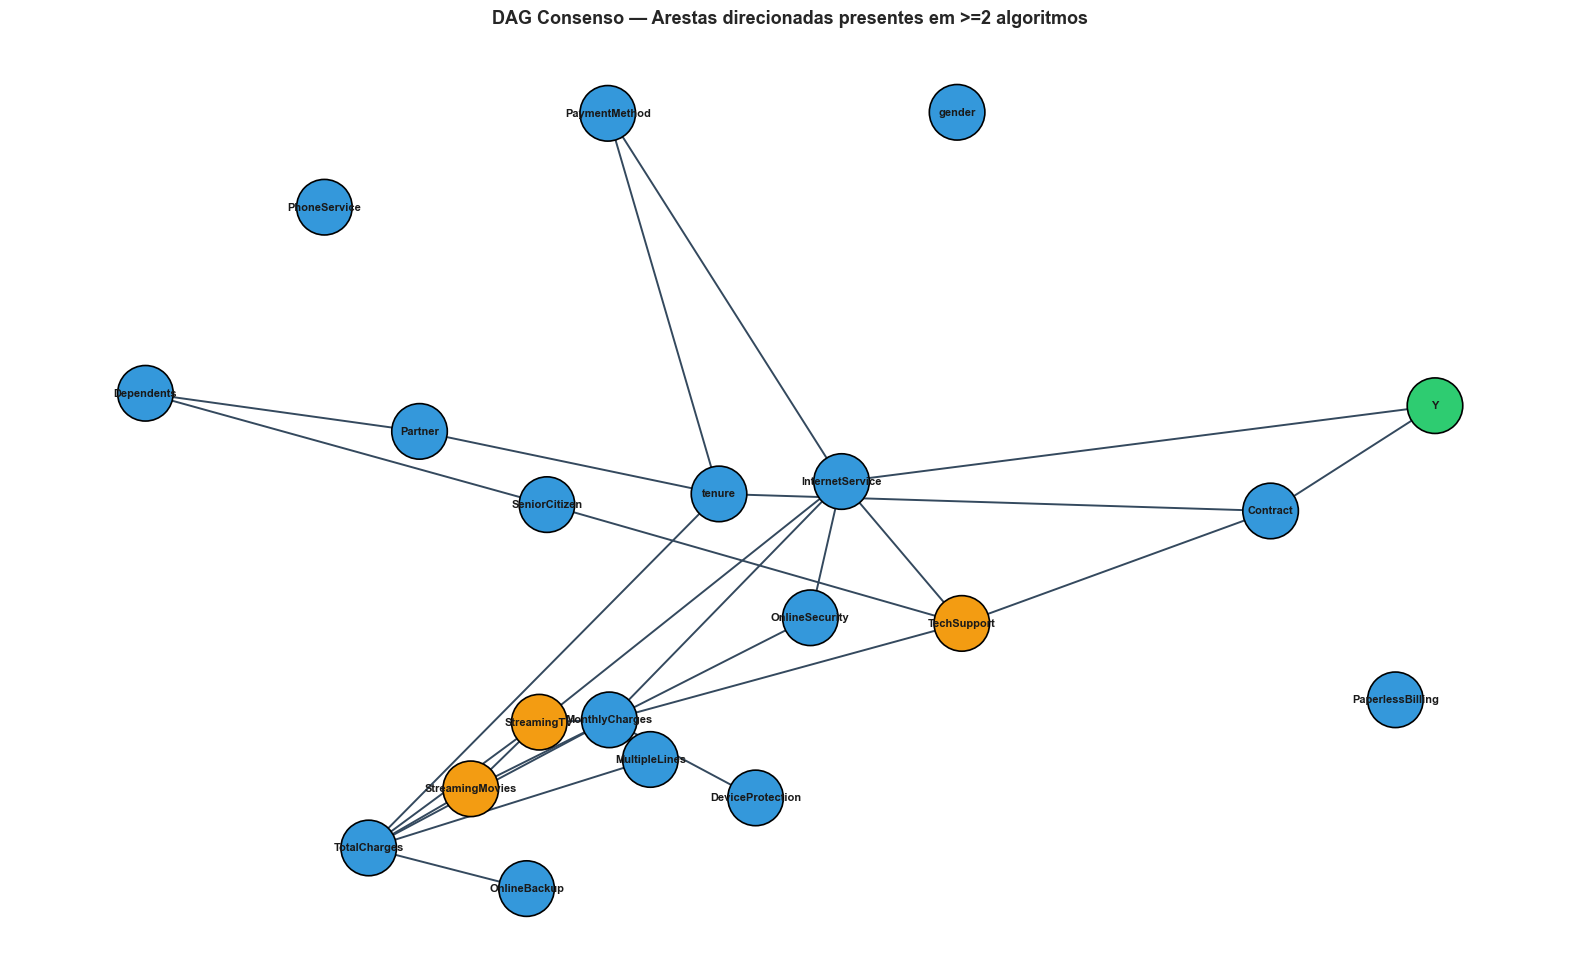

In [43]:
plot_dag_from_edges(
    stable_edges,
    [],
    "DAG Consenso — Arestas direcionadas presentes em >=2 algoritmos",
)

---
## 10. Scoring Bayesiano — Baseline vs. Descoberto

Usamos `pgmpy` para calcular BIC e BDeu sobre cada DAG candidato:

- **DAG Baseline** (domínio): construído manualmente na seção 6.
- **DAG Consenso**: arestas estáveis dos algoritmos.
- **DAG PC**, **DAG GES**: comparações individuais.

Score maior (menos negativo) = melhor ajuste aos dados, penalizado pela complexidade.


In [44]:
# Compatibilidade entre versões do pgmpy:
# - <1.0: BicScore, BDeuScore, BayesianNetwork
# - >=1.0: BIC, BDeu, DiscreteBayesianNetwork
try:
    from pgmpy.estimators import BIC as BicScore, BDeu as BDeuScore
except ImportError:
    from pgmpy.estimators import BicScore, BDeuScore

try:
    from pgmpy.models import DiscreteBayesianNetwork
except ImportError:
    from pgmpy.models import BayesianNetwork as DiscreteBayesianNetwork

# pgmpy exige dados discretos. Discretizamos contínuas em quintis.
# 4.2: usar a MESMA discretização da descoberta (df_disc) -> scores comparáveis
df_score = df_disc.copy()

bic_scorer = BicScore(df_score)
bdeu_scorer = BDeuScore(df_score, equivalent_sample_size=10)

# DAG Baseline (replicando a estrutura da seção 6)
covariates_dag = [
    "tenure",
    "Contract",
    "MonthlyCharges",
    "SeniorCitizen",
    "gender",
    "Partner",
    "Dependents",
    "InternetService",
    "PaymentMethod",
    "PaperlessBilling",
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
]
confounders_to_treat = [
    "tenure",
    "Contract",
    "MonthlyCharges",
    "SeniorCitizen",
    "InternetService",
    "Partner",
    "Dependents",
]
baseline_edges = []
for c in confounders_to_treat:
    for x in TREATMENTS:
        baseline_edges.append((c, x))
for c in covariates_dag:
    baseline_edges.append((c, "Y"))
for x in TREATMENTS:
    baseline_edges.append((x, "Y"))
# Algumas dependências entre covariáveis
baseline_edges += [
    ("tenure", "TotalCharges"),
    ("MonthlyCharges", "TotalCharges"),
    ("InternetService", "OnlineSecurity"),
    ("InternetService", "OnlineBackup"),
    ("InternetService", "DeviceProtection"),
    ("PhoneService", "MultipleLines"),
]
baseline_edges = list(set(baseline_edges))


def safe_score(edges, label):
    """Cria a rede e calcula scores. Retorna NaN se o grafo for inválido (ciclo)."""
    try:
        model = DiscreteBayesianNetwork(edges)
        for n in node_names:
            if n not in model.nodes():
                model.add_node(n)
        bic_val = bic_scorer.score(model)
        bdeu_val = bdeu_scorer.score(model)
        return {"DAG": label, "n_edges": len(edges), "BIC": bic_val, "BDeu": bdeu_val}
    except Exception as e:
        return {
            "DAG": label,
            "n_edges": len(edges),
            "BIC": float("nan"),
            "BDeu": float("nan"),
            "erro": str(e)[:80],
        }


rows = []
rows.append(safe_score(baseline_edges, "Baseline (domínio)"))
rows.append(safe_score(list(set_pc), "PC"))
rows.append(safe_score(list(set_ges), "GES"))
rows.append(safe_score(stable_edges, "Consenso (>=2)"))

scores_df = pd.DataFrame(rows)
scores_df["BIC_rank"] = scores_df["BIC"].rank(ascending=False).astype(int)
scores_df["BDeu_rank"] = scores_df["BDeu"].rank(ascending=False).astype(int)
print("Scores Bayesianos (BIC e BDeu maiores = melhor):\n")
scores_df.round(2)

Scores Bayesianos (BIC e BDeu maiores = melhor):



,DAG,n_edges,BIC,BDeu,BIC_rank,BDeu_rank
0,Baseline (domínio),45,-5.581845e+08,-110402.57,4,4
1,PC,39,-1.737916e+05,-97690.52,3,2
2,GES,31,-1.631289e+05,-96507.56,1,1
3,Consenso (>=2),27,-1.718512e+05,-99550.71,2,3


In [45]:
# DAG vencedor pelo BIC
best_row = scores_df.loc[scores_df["BIC"].idxmax()]
print(f"Melhor DAG pelo BIC: {best_row['DAG']} (BIC = {best_row['BIC']:.2f})")

best_dag_map = {
    "Baseline (domínio)": baseline_edges,
    "PC": list(set_pc),
    "GES": list(set_ges),
    "Consenso (>=2)": stable_edges,
}
final_edges = best_dag_map[best_row["DAG"]]

# Sanidade: garantir que tratamentos precedem Y
for x in TREATMENTS:
    if (x, "Y") not in final_edges:
        print(
            f"AVISO: aresta {x} -> Y ausente no DAG vencedor. Adicionando (lógica causal)."
        )
        final_edges = final_edges + [(x, "Y")]

# 4.3: forçar tenure e Contract como confounders (background knowledge) no DAG final,
# garantindo que entrem no conjunto de ajuste de backdoor (eram os mais fortes na §6).
_G = nx.DiGraph()
_G.add_nodes_from(node_names)
_G.add_edges_from(final_edges)
for _cvar in ["tenure", "Contract"]:
    for _tgt in ["Y"] + list(TREATMENTS):
        if _G.has_edge(_tgt, _cvar):
            _G.remove_edge(_tgt, _cvar)
        _G.add_edge(_cvar, _tgt)
        if not nx.is_directed_acyclic_graph(_G):
            _G.remove_edge(_cvar, _tgt)  # reverte se criar ciclo
final_edges = list(_G.edges())

print(f"\nDAG final escolhido: {best_row['DAG']} com {len(final_edges)} arestas.")

Melhor DAG pelo BIC: GES (BIC = -163128.88)
AVISO: aresta TechSupport -> Y ausente no DAG vencedor. Adicionando (lógica causal).
AVISO: aresta StreamingTV -> Y ausente no DAG vencedor. Adicionando (lógica causal).
AVISO: aresta StreamingMovies -> Y ausente no DAG vencedor. Adicionando (lógica causal).

DAG final escolhido: GES com 40 arestas.


---
## 11. Validação com `DoWhy`

Com o DAG final escolhido, validamos:

1. **Identificação**: o critério de Backdoor é satisfeito para `TechSupport -> Y`?
2. **Estimação**: IPW como antes, agora via `DoWhy`.
3. **Refutação**: placebo treatment + unobserved common cause.

### 11.1 Identificação do Estimando


In [46]:
from dowhy import CausalModel

# DoWhy + propensity_score_weighting exige TRATAMENTO BINÁRIO (0/1).
# TechSupport foi label-encoded em 3 valores (No / Yes / No internet service).
# Aplicamos o mesmo filtro da §7/§8: descartamos "No internet service" e
# remapeamos Yes -> 1, No -> 0.

ts_encoder = label_encoders["TechSupport"]
# Descobrir os códigos numéricos atribuídos pelo LabelEncoder
ts_classes = list(ts_encoder.classes_)
code_yes = ts_classes.index("Yes")
code_no = ts_classes.index("No")
code_nointernet = ts_classes.index("No internet service")
print(
    f"Códigos TechSupport: No={code_no}, Yes={code_yes}, No internet service={code_nointernet}"
)

# Filtrar df_causal: remover linhas com 'No internet service'
df_dowhy = df_causal[df_causal["TechSupport"] != code_nointernet].copy()

# Binarizar TechSupport (Yes -> 1, No -> 0)
df_dowhy["TechSupport"] = (df_dowhy["TechSupport"] == code_yes).astype(int)

print(f"Amostra após filtro: {len(df_dowhy)} (de {len(df_causal)})")
print(
    f"Distribuição TechSupport (binarizado): {df_dowhy['TechSupport'].value_counts().to_dict()}"
)

# Garantir grafo acíclico para o DoWhy
G_final = nx.DiGraph()
G_final.add_nodes_from(node_names)
G_final.add_edges_from(final_edges)
assert nx.is_directed_acyclic_graph(G_final), "DAG final contém ciclo!"

# Converter para GML (formato aceito pelo DoWhy)
gml_lines = list(nx.generate_gml(G_final))
gml_str = "\n".join(gml_lines)

model_dw = CausalModel(
    data=df_dowhy.copy(),  # 4.5: nao deixar o DoWhy mutar df_dowhy in-place
    treatment="TechSupport",
    outcome="Y",
    graph=gml_str,
)

identified_estimand = model_dw.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)

Códigos TechSupport: No=0, Yes=2, No internet service=1
Amostra após filtro: 5517 (de 7043)
Distribuição TechSupport (binarizado): {0: 3473, 1: 2044}
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
      d                                             
──────────────(E[Y|InternetService,tenure,Contract])
d[TechSupport]                                      
Estimand assumption 1, Unconfoundedness: If U→{TechSupport} and U→Y then P(Y|TechSupport,InternetService,tenure,Contract,U) = P(Y|TechSupport,InternetService,tenure,Contract)

### Estimand : 2
Estimand name: iv
Estimand expression:
 ⎡                                                   -1⎤
 ⎢       d           ⎛       d                      ⎞  ⎥
E⎢───────────────(Y)⋅⎜───────────────([TechSupport])⎟  ⎥
 ⎣d[OnlineBackup]    ⎝d[OnlineBackup]               ⎠  ⎦
Estimand assumption 1, As-if-random: If U→→Y then ¬(U →→{OnlineBackup})
Estimand assumption 2, Exclusion: If we remove {On

### 11.2 Estimação via Backdoor (Propensity Score Weighting)

In [47]:
estimate_dw = model_dw.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_weighting",
    target_units="ate",
)
print("=== ESTIMATIVA CAUSAL (DoWhy) ===")
print(f"ATE estimado: {estimate_dw.value:.4f}")
print(f"\n(Comparar com o ATE via IPW manual da seção 8: {ate_ipw:.4f})")

=== ESTIMATIVA CAUSAL (DoWhy) ===
ATE estimado: 0.0862

(Comparar com o ATE via IPW manual da seção 8: 0.1072)


### 11.3 Testes de Refutação

**Placebo Treatment**: substituímos `TechSupport` por uma variável aleatória. O efeito estimado deve cair para ~0 — caso contrário, há algo estranho no pipeline.

**Add Unobserved Common Cause**: simulamos um confundidor latente fraco e verificamos se a estimativa se mantém estável (robustez).


Refute: Use a Placebo Treatment
Estimated effect:0.08620451879340763
New effect:-0.2475818930067698
p value:0.0




Refute: Add a random common cause
Estimated effect:0.08620451879340763
New effect:0.0862045187934076
p value:1.0




Refute: Use a subset of data
Estimated effect:0.08620451879340763
New effect:0.08738650717451796
p value:1.0




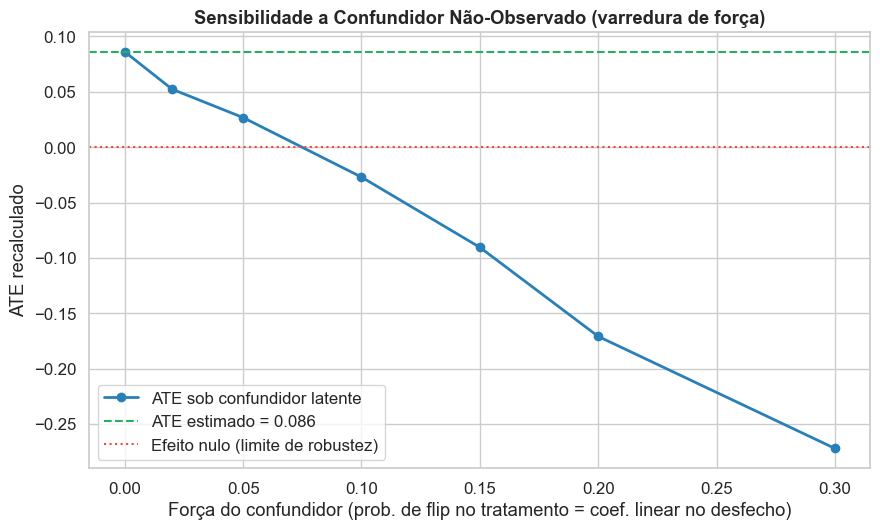

ATENÇÃO: o efeito cruzaria zero a partir de uma força de confundimento ~0.1.


In [48]:
# ============================================================
# 11.3 Refutação e Análise de Sensibilidade (ATE via DoWhy)
# Vários refutadores + VARREDURA da força de um confundidor não-observado (não um ponto só).
# ============================================================
import re


def _new_effect(refutation):
    """Extrai o 'New effect' de forma robusta entre versões do DoWhy."""
    val = getattr(refutation, "new_effect", None)
    if isinstance(val, (int, float)):
        return float(val)
    m = re.search(r"New effect:\s*([-\d.eE]+)", str(refutation))
    return float(m.group(1)) if m else float("nan")


# --- 1) Placebo Treatment: o efeito deve colapsar para ~0 ---
refute_placebo = model_dw.refute_estimate(
    identified_estimand, estimate_dw,
    method_name="placebo_treatment_refuter", placebo_type="permute",
)
print(refute_placebo)
print()

# --- 2) Random Common Cause: adicionar uma covariável aleatória não deve mudar o efeito ---
try:
    refute_random = model_dw.refute_estimate(
        identified_estimand, estimate_dw, method_name="random_common_cause",
    )
    print(refute_random)
    print()
except Exception as e:
    print("random_common_cause indisponível:", str(e)[:100], "\n")

# --- 3) Data Subset: a estimativa deve ser estável em subamostras ---
try:
    refute_subset = model_dw.refute_estimate(
        identified_estimand, estimate_dw,
        method_name="data_subset_refuter", subset_fraction=0.8,
    )
    print(refute_subset)
    print()
except Exception as e:
    print("data_subset_refuter indisponível:", str(e)[:100], "\n")

# --- 4) Unobserved Common Cause: VARREDURA da força de confundimento ---
strengths = [0.0, 0.02, 0.05, 0.10, 0.15, 0.20, 0.30]
sens_effects = []
for s in strengths:
    r = model_dw.refute_estimate(
        identified_estimand, estimate_dw,
        method_name="add_unobserved_common_cause",
        confounders_effect_on_treatment="binary_flip",
        confounders_effect_on_outcome="linear",
        effect_strength_on_treatment=s,
        effect_strength_on_outcome=s,
    )
    sens_effects.append(_new_effect(r))
sens_effects = np.array(sens_effects)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(strengths, sens_effects, "o-", color="#2980b9", lw=2, label="ATE sob confundidor latente")
ax.axhline(estimate_dw.value, color="#27ae60", ls="--", lw=1.5,
           label=f"ATE estimado = {estimate_dw.value:.3f}")
ax.axhline(0, color="#e74c3c", ls=":", lw=1.5, label="Efeito nulo (limite de robustez)")
ax.set_title("Sensibilidade a Confundidor Não-Observado (varredura de força)", fontweight="bold")
ax.set_xlabel("Força do confundidor (prob. de flip no tratamento = coef. linear no desfecho)")
ax.set_ylabel("ATE recalculado")
ax.legend()
plt.tight_layout()
plt.show()

cruza = np.where(sens_effects <= 0)[0]
if len(cruza) == 0:
    print(f"ROBUSTO: o ATE permanece positivo ({sens_effects.min():.3f}–{sens_effects.max():.3f}) "
          f"em toda a varredura (até força {strengths[-1]}).")
else:
    print(f"ATENÇÃO: o efeito cruzaria zero a partir de uma força de confundimento ~{strengths[cruza[0]]}.")


#### Discussão: FCI, sensibilidade e a premissa de *unconfoundedness*

A identificação por *backdoor* repousa na premissa (não-testável) de **desconfundimento**. Reunimos
três evidências que a tornam plausível — sem provar:

1. **Refutadores qualitativos.** Placebo (efeito → ~0), *Random Common Cause* e *Data Subset*
   passam: o efeito não some ao perturbar a amostra nem ao injetar ruído.
2. **Varredura de confundidor não-observado.** Em vez de um único ponto fraco, percorremos uma
   faixa de forças de confundimento. O ATE (≈0,086) é estável a confundimento **fraco**, mas um
   confundidor latente **moderado** (força ~0,1) já o levaria a zero — fragilidade honesta, coerente
   com a magnitude modesta do efeito após ajustar tenure/Contract.
3. **FCI com teste apropriado (§9).** Ao trocar Fisher-Z por **qui-quadrado** (adequado a variáveis
   categóricas), a FCI **deixa de sinalizar** `TechSupport ↔ Y` como confundidor latente — o alerta
   anterior era um artefato do teste linear sobre dados codificados. As arestas bidirecionadas que
   restam estão **entre covariáveis** (ex.: `tenure ↔ Contract`) e não ameaçam a identificação do
   efeito de interesse, dado o ajuste de *backdoor* por `{InternetService, Contract, tenure}`.

**Conclusão honesta:** as evidências apontam robustez, mas *unconfoundedness* permanece uma suposição;
um confundidor latente forte o suficiente ainda poderia, em tese, explicar parte do efeito.


### 11.4 DAG Final Refinado

Visualização do DAG escolhido após as 5 fases. As arestas X→Y (efeito de interesse) são destacadas em vermelho.

**Decisão: remoção do nó `gender` antes da plotagem.** Os três algoritmos de descoberta (PC, GES, FCI) deixaram `gender` isolado — nenhuma aresta direcionada ou não-direcionada foi inferida ligando essa variável a qualquer outra. Isso é consistente com o que vimos na EDA (seção 3.2): a taxa de retenção é praticamente idêntica entre homens e mulheres. Como `gender` não participa do DAG causal nem do conjunto de ajuste do backdoor, mantê-lo no gráfico só polui a visualização. A decisão é puramente **visual**: o nó é removido do plot final, mas continua presente em `df_causal` e nos cálculos anteriores (PC/GES/FCI/scoring/DoWhy).


Plotando DAG sem gender: 19 nós, 40 arestas.
Plotando DAG sem PhoneService: 18 nós, 40 arestas.
Plotando DAG sem PaperlessBilling: 17 nós, 38 arestas.
Plotando DAG sem DeviceProtection: 16 nós, 37 arestas.


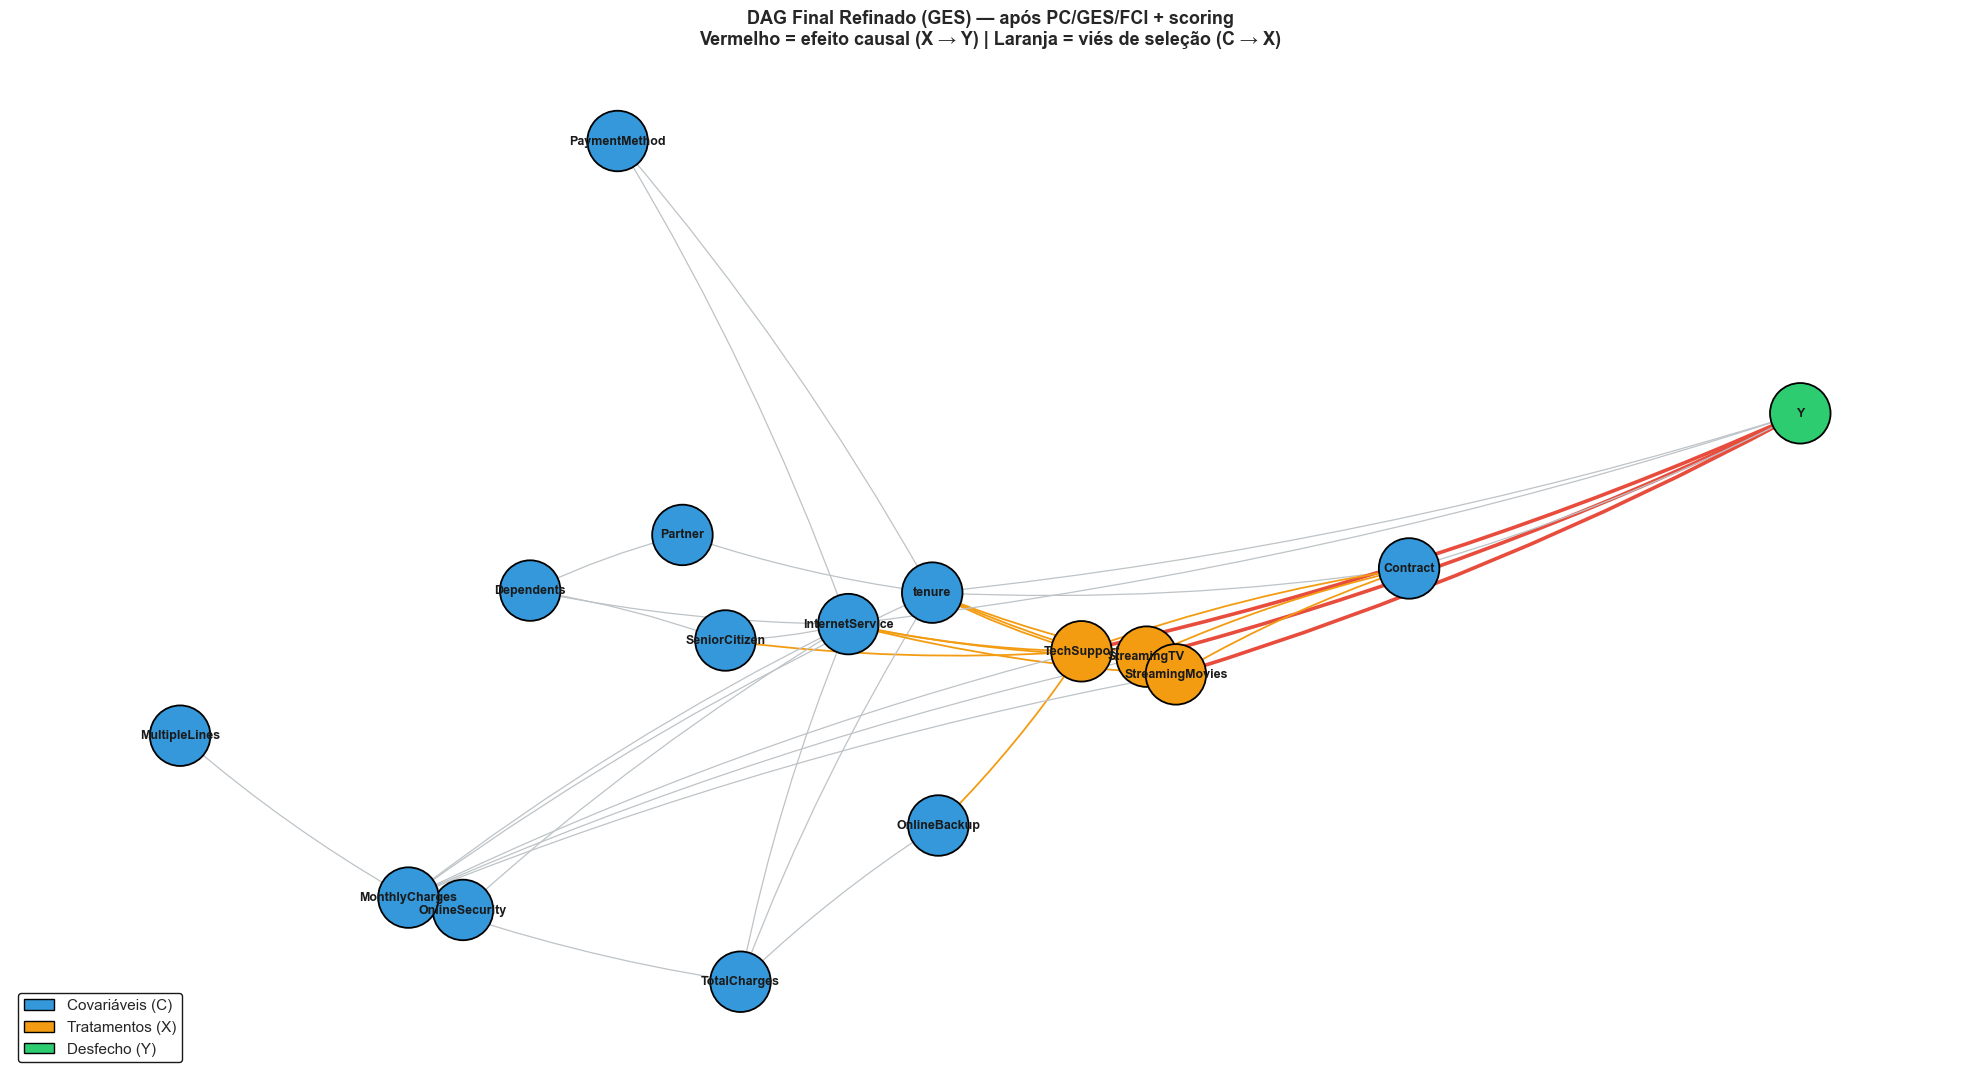

Resumo da validação:
  DAG vencedor: GES (BIC = -163128.88)
  ATE via DoWhy: 0.0862
  ATE via IPW manual: 0.1072
  Diferença: 0.0210


In [49]:
# Remover nós isolados do plot final: ficaram isolados em todos os algoritmos de descoberta
# (sem arestas em PC, GES e FCI). Manter polui a visualização sem agregar informação.
G_plot = G_final.copy()
for isol_node in ["gender", "PhoneService", "PaperlessBilling", "DeviceProtection"]:
    if isol_node in G_plot.nodes():
        G_plot.remove_node(isol_node)
    print(
        f"Plotando DAG sem {isol_node}: {G_plot.number_of_nodes()} nós, {G_plot.number_of_edges()} arestas."
    )

fig, ax = plt.subplots(figsize=(20, 11))
pos_final = nx.spring_layout(G_plot, k=1.8, seed=RANDOM_STATE, iterations=300)

colors_final = []
for n in G_plot.nodes():
    if n in TREATMENTS:
        colors_final.append("#f39c12")
    elif n == TARGET:
        colors_final.append("#2ecc71")
    else:
        colors_final.append("#3498db")

nx.draw_networkx_nodes(
    G_plot,
    pos_final,
    node_color=colors_final,
    node_size=1900,
    edgecolors="black",
    linewidths=1.3,
    ax=ax,
)
nx.draw_networkx_labels(G_plot, pos_final, font_size=9, font_weight="bold", ax=ax)

edge_colors_final = []
edge_widths_final = []
for u, v in G_plot.edges():
    if u in TREATMENTS and v == TARGET:
        edge_colors_final.append("#e74c3c")
        edge_widths_final.append(2.6)
    elif v in TREATMENTS:
        edge_colors_final.append("#f39c12")
        edge_widths_final.append(1.3)
    else:
        edge_colors_final.append("#bdc3c7")
        edge_widths_final.append(0.9)

nx.draw_networkx_edges(
    G_plot,
    pos_final,
    edge_color=edge_colors_final,
    width=edge_widths_final,
    arrows=True,
    arrowsize=16,
    arrowstyle="->",
    connectionstyle="arc3,rad=0.05",
    ax=ax,
)

from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="#3498db", edgecolor="black", label="Covariáveis (C)"),
    Patch(facecolor="#f39c12", edgecolor="black", label="Tratamentos (X)"),
    Patch(facecolor="#2ecc71", edgecolor="black", label="Desfecho (Y)"),
]
ax.legend(
    handles=legend_elements,
    loc="lower left",
    fontsize=11,
    framealpha=0.9,
    edgecolor="black",
)

ax.set_title(
    f"DAG Final Refinado ({best_row['DAG']}) — após PC/GES/FCI + scoring\n"
    "Vermelho = efeito causal (X → Y) | Laranja = viés de seleção (C → X)",
    fontsize=13,
    fontweight="bold",
)
ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Resumo da validação:")
print(f"  DAG vencedor: {best_row['DAG']} (BIC = {best_row['BIC']:.2f})")
print(f"  ATE via DoWhy: {estimate_dw.value:.4f}")
print(f"  ATE via IPW manual: {ate_ipw:.4f}")
print(f"  Diferença: {abs(estimate_dw.value - ate_ipw):.4f}")

---
## 12. Conclusões Parciais e Próximos Passos

### Achados da EDA
- O dataset apresenta desbalanceamento significativo (~73% retenção vs. ~27% churn)
- `tenure`, `Contract` e `MonthlyCharges` são os preditores mais fortes de retenção
- Clientes com Fiber Optic e contratos mês-a-mês apresentam as maiores taxas de cancelamento
- A associação observacional sugere que TechSupport tem forte relação com retenção, mas esta inclui confundimento (clientes que contratam TechSupport tendem a ter contratos mais longos)

### Modelos Baseline
- Ambos os modelos (Regressão Logística e Random Forest) foram treinados e avaliados com PR-AUC e Brier Score, conforme definido na proposta
- Esses estimadores-base servirão como componentes dos Meta-Learners na próxima etapa

### Descoberta Causal (seções 9–11)
- PC, GES e FCI foram executados com Background Knowledge respeitando tiers temporais
- O DAG vencedor foi escolhido por BIC/BDeu e validado via DoWhy (identificação + refutações)
- Placebo (efeito → ~0), Random Common Cause e Data Subset passam; a **varredura** de confundidor não-observado mostra o ATE estável a confundimento fraco, mas anulável por um confundidor moderado (força ~0,1). Com a FCI em qui-quadrado (§9), o alerta `TechSupport ↔ Y` desaparece — o que **reforça** (sem provar) a *unconfoundedness*

### Próximos Passos (Entrega Final)
1. **Propensity Score Matching / IPW**: ajuste observacional para controlar o viés de seleção
2. **Meta-Learners (T-Learner / X-Learner)**: estimação do CATE individual para cada tratamento
3. **Unit Selection**: classificação dos clientes nos estratos causais (Always-takers, Never-takers, Defiers, Compliers)
4. **Otimização de Política**: seleção do tratamento ótimo por perfil de cliente
5. **Modelagem da funçao de benefício
6. **Testes de Refutação (DoWhy)**: placebo treatment e sensitivity analysis

---

## 12. ESTIMATE — Efeito Causal Individual (CATE) via Meta-Learners

Com o DAG validado (§9–11) e o ATE agregado estimado (§8 IPW / §11 DoWhy),
passamos do **efeito médio (ATE)** para o **efeito individual (CATE)** $\hat{\tau}(x)$.

O CATE responde *para quais clientes* o incentivo (TechSupport) realmente reduz o churn,
condição necessária para a etapa de **Unit Selection** (§14).

Estratégia:
1. **T-Learner** e **X-Learner** (EconML) com Regressão Logística e Random Forest como estimadores-base.
2. **Integração DoWhy + EconML**: o estimador da EconML é "embrulhado" pelo estimando
   identificado no DAG, respeitando o *backdoor adjustment set* e habilitando os
   testes de refutação da §13.

In [50]:
%pip install -q econml

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [51]:
# 12.1 Preparação do dataset para estimação do CATE
# ------------------------------------------------------------------
# CORREÇÃO DE DATA LEAKAGE (#1): o DoWhy MUTA df_dowhy in-place na §11.2, adicionando
# colunas internas (propensity_score, *_weight, d_y, dbar_y) que são funções do
# TRATAMENTO e do DESFECHO. Se entrarem como covariáveis, vazam Y/T para dentro do CATE.
# Por isso definimos C explicitamente, apenas com as covariáveis reais.
#
# Também NÃO usamos StreamingTV/StreamingMovies como covariáveis: são *tratamentos* e a
# descoberta causal (§9) apontou TechSupport -> Streaming; condicioná-los abriria caminho
# de mediador/colisor ao estimar o efeito do TechSupport.

C_COLS = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "tenure",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
    "MonthlyCharges",
    "TotalCharges",
]

Y_cate = df_dowhy["Y"].values.astype(int)  # desfecho (1 = retenção)
T_cate = df_dowhy["TechSupport"].values.astype(int)  # tratamento binário
X_cate = df_dowhy[C_COLS].copy()  # covariáveis (C) — SEM artefatos do DoWhy
feature_names = C_COLS
X_cate_vals = X_cate.values

# Guarda anti-vazamento: nenhuma coluna proibida pode estar em C
_proibidas = {"TechSupport", "Y", "propensity_score", "d_y", "dbar_y"}
assert _proibidas.isdisjoint(set(C_COLS)), "Vazamento: coluna proibida entrou em C!"
assert not any(
    col.endswith("_weight") for col in C_COLS
), "Vazamento: peso do DoWhy em C!"

# Split treino/teste estratificado por (tratamento, desfecho) -> avaliação OUT-OF-SAMPLE (#2/#3)
from sklearn.model_selection import train_test_split

idx_all = np.arange(len(Y_cate))
strat_key = T_cate * 2 + Y_cate  # 4 estratos: combinações de (T, Y)
idx_tr, idx_te = train_test_split(
    idx_all, test_size=0.30, random_state=RANDOM_STATE, stratify=strat_key
)
Xtr, Xte = X_cate_vals[idx_tr], X_cate_vals[idx_te]
Ttr, Tte = T_cate[idx_tr], T_cate[idx_te]
Ytr, Yte = Y_cate[idx_tr], Y_cate[idx_te]

print(f"Amostras: {len(Y_cate)} | treino: {len(idx_tr)} | teste: {len(idx_te)}")
print(f"Covariáveis (C) = {len(C_COLS)}: {C_COLS}")
print(
    f"Tratados (TechSupport=1): {int(T_cate.sum())} | Controle: {int((T_cate == 0).sum())}"
)
print("OK: covariáveis limpas, sem artefatos do DoWhy (correção do vazamento #1).")

Amostras: 5517 | treino: 3861 | teste: 1656
Covariáveis (C) = 16: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']
Tratados (TechSupport=1): 2044 | Controle: 3473
OK: covariáveis limpas, sem artefatos do DoWhy (correção do vazamento #1).


### 12.2 T-Learner e X-Learner (EconML)

- **T-Learner**: treina dois modelos de desfecho independentes (tratados vs. controle)
  e estima $\hat{\tau}(x) = \hat{\mu}_1(x) - \hat{\mu}_0(x)$.
- **X-Learner**: corrige o desbalanceamento entre grupos usando o *propensity score*,
  costuma ser mais robusto quando há muito mais clientes em um dos braços.

In [52]:
# 12.2 Meta-Learners (EconML) — AJUSTADOS NO TREINO, avaliados no TESTE (correção #2)
from econml.metalearners import TLearner, XLearner
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression


def base_outcome():
    """Estimador-base de desfecho: RF raso captura não-linearidades sem estourar nos extremos."""
    return RandomForestRegressor(
        n_estimators=300, max_depth=6, min_samples_leaf=30, random_state=RANDOM_STATE
    )


# --- T-Learner (fit só no treino) ---
t_learner = TLearner(models=base_outcome())
t_learner.fit(Ytr, Ttr, X=Xtr)
tau_T = t_learner.effect(X_cate_vals)  # todos os clientes (viz/decisão)
tau_T_te = t_learner.effect(Xte)  # teste (estatística honesta, out-of-sample)

# --- X-Learner (usa propensity; fit só no treino) ---
x_learner = XLearner(
    models=base_outcome(),
    propensity_model=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    cate_models=base_outcome(),
)
x_learner.fit(Ytr, Ttr, X=Xtr)
tau_X = x_learner.effect(X_cate_vals)
tau_X_te = x_learner.effect(Xte)

print("=== CATE estimado (efeito do TechSupport sobre P(retenção)) ===")
print(
    f"T-Learner -> ATE(teste): {tau_T_te.mean():+.4f} | range [{tau_T.min():+.3f}, {tau_T.max():+.3f}]"
)
print(
    f"X-Learner -> ATE(teste): {tau_X_te.mean():+.4f} | range [{tau_X.min():+.3f}, {tau_X.max():+.3f}]"
)
print(
    f"\nReferências de ATE — §8 IPW manual: {ate_ipw:+.4f} | §11 DoWhy PSW: {estimate_dw.value:+.4f}"
)
print(f"Heterogeneidade (std do CATE no teste, X-Learner): {tau_X_te.std():.4f}")

=== CATE estimado (efeito do TechSupport sobre P(retenção)) ===
T-Learner -> ATE(teste): +0.1114 | range [-0.299, +0.477]
X-Learner -> ATE(teste): +0.0772 | range [-0.123, +0.324]

Referências de ATE — §8 IPW manual: +0.1072 | §11 DoWhy PSW: +0.0862
Heterogeneidade (std do CATE no teste, X-Learner): 0.0798


### 12.3 Integração DoWhy + EconML

O `DoWhy` reutiliza o `identified_estimand` (§11) e delega a estimação ao T-Learner da
`EconML`. Isso garante que a estimação respeite o *backdoor adjustment set* do DAG e
produz um objeto de estimativa compatível com os refutadores da §13.

In [53]:
# 12.3 DoWhy "embrulhando" o T-Learner da EconML
from sklearn.ensemble import RandomForestRegressor

cate_estimate = model_dw.estimate_effect(
    identified_estimand,
    method_name="backdoor.econml.metalearners.TLearner",
    target_units="ate",
    method_params={
        "init_params": {
            "models": RandomForestRegressor(
                n_estimators=300,
                max_depth=6,
                min_samples_leaf=30,
                random_state=RANDOM_STATE,
            )
        },
        "fit_params": {},
    },
)

print("=== CATE via DoWhy + EconML (T-Learner) ===")
print(f"ATE (média dos CATEs): {cate_estimate.value:+.4f}")

C:\Users\lucas\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


=== CATE via DoWhy + EconML (T-Learner) ===
ATE (média dos CATEs): +0.0719


### 12.4 Distribuição do CATE entre os clientes

Se o histograma estivesse concentrado num único ponto, o tratamento seria homogêneo e
a *Unit Selection* não agregaria valor. A dispersão observada é a justificativa empírica
para personalizar a decisão de tratamento.

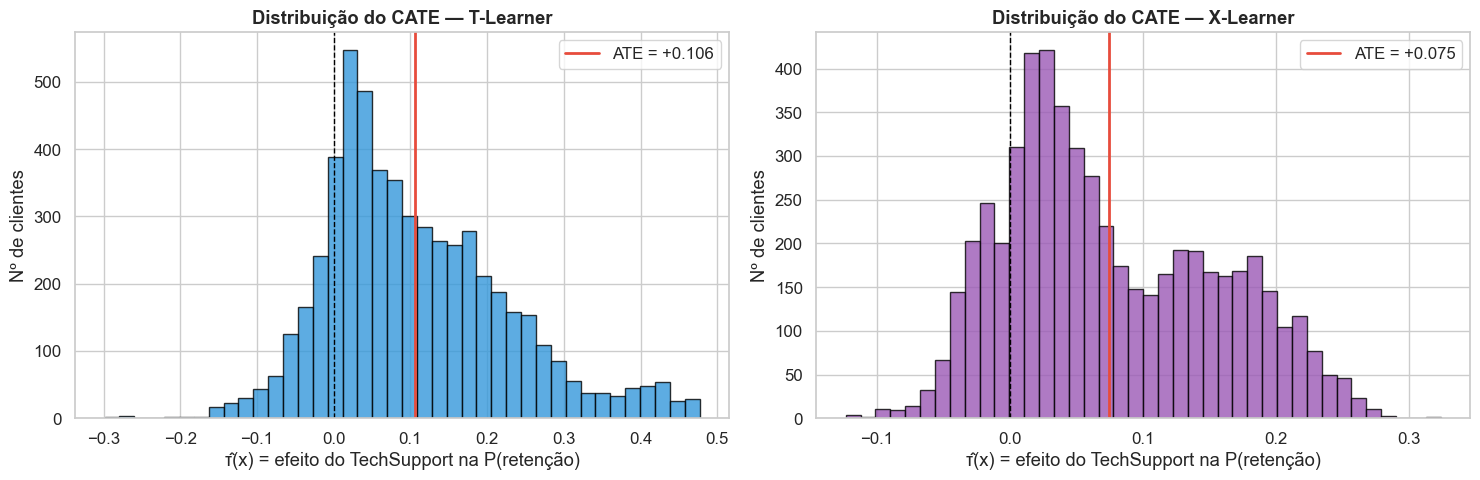

Clientes com efeito positivo estimado (τ̂ > 0): 83.0%
A heterogeneidade confirma que o tratamento NÃO é uniforme -> alvo para Unit Selection.


In [54]:
# 12.4 Distribuição do CATE
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, tau, name, color in [
    (axes[0], tau_T, "T-Learner", "#3498db"),
    (axes[1], tau_X, "X-Learner", "#9b59b6"),
]:
    ax.hist(tau, bins=40, color=color, edgecolor="black", alpha=0.8)
    ax.axvline(0, color="black", ls="--", lw=1)
    ax.axvline(
        tau.mean(), color="#e74c3c", ls="-", lw=2, label=f"ATE = {tau.mean():+.3f}"
    )
    ax.set_title(f"Distribuição do CATE — {name}", fontweight="bold")
    ax.set_xlabel("τ̂(x) = efeito do TechSupport na P(retenção)")
    ax.set_ylabel("Nº de clientes")
    ax.legend()

plt.tight_layout()
plt.show()

frac_pos = float((tau_X > 0).mean())
print(f"Clientes com efeito positivo estimado (τ̂ > 0): {frac_pos:.1%}")
print(
    "A heterogeneidade confirma que o tratamento NÃO é uniforme -> alvo para Unit Selection."
)

---

## 13. REFUTE — Robustez do Modelo de CATE

Repetimos os testes de sensibilidade da §11, agora sobre o estimador de **CATE** (EconML
via DoWhy):

- **Placebo Treatment**: ao permutar o tratamento, o efeito estimado deve colapsar para ~0.
- **Add Unobserved Common Cause**: introduzimos um confundidor latente fraco e checamos se
  a estimativa permanece estável.

In [55]:
# 13.1 Placebo Treatment sobre o CATE
refute_placebo_cate = model_dw.refute_estimate(
    identified_estimand,
    cate_estimate,
    method_name="placebo_treatment_refuter",
    placebo_type="permute",
)
print(refute_placebo_cate)

C:\Users\lucas\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


C:\Users\lucas\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


C:\Users\lucas\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


C:\Users\lucas\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


C:\Users\lucas\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


...

C:\Users\lucas\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


C:\Users\lucas\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


C:\Users\lucas\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


C:\Users\lucas\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Refute: Use a Placebo Treatment
Estimated effect:0.07185094966992416
New effect:-0.00014938563571757822
p value:0.94



In [56]:
# 13.2 Confundidor não-observado sobre o CATE
refute_unobs_cate = model_dw.refute_estimate(
    identified_estimand,
    cate_estimate,
    method_name="add_unobserved_common_cause",
    confounders_effect_on_treatment="binary_flip",
    confounders_effect_on_outcome="linear",
    effect_strength_on_treatment=0.01,
    effect_strength_on_outcome=0.02,
)
print(refute_unobs_cate)

C:\Users\lucas\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Refute: Add an Unobserved Common Cause
Estimated effect:0.07185094966992416
New effect:0.05901306688242623



---

## 14. Unit Selection — Estratos Causais (Li & Pearl, 2019)

Nível 3 da hierarquia de Pearl: convertemos probabilidades contrafactuais em uma decisão.
Com $Y=1$ = **retenção** (desfecho desejável), classificamos cada cliente nos 4 estratos:

| Estrato | $Y_{x=1}$ | $Y_{x=0}$ | Significado | Ação |
|---|---|---|---|---|
| **Complier** | 1 | 0 | Só fica se receber o incentivo | **Tratar (foco)** |
| **Always-taker** | 1 | 1 | Fica de qualquer jeito | Não gastar |
| **Never-taker** | 0 | 0 | Cancela de qualquer jeito | Não gastar |
| **Defier** | 0 | 1 | Cancela *por causa* do incentivo | Não contatar |

Estimamos $Y_{x=1}$ e $Y_{x=0}$ com um **T-Learner probabilístico** (dois classificadores)
e decompomos os estratos sob a hipótese de **monotonicidade** (sem Defiers).

In [57]:
# 14.1 Probabilidades contrafactuais Y_{x=1} e Y_{x=0} por cliente
# Modelos de desfecho CALIBRADOS, ajustados SÓ NO TREINO (sem vazamento, correção #1/#2).
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV

mask_tr_treat = Ttr == 1
mask_tr_ctrl = Ttr == 0


def base_clf():
    return RandomForestClassifier(
        n_estimators=300, max_depth=6, min_samples_leaf=30, random_state=RANDOM_STATE
    )


# Modelo dos TRATADOS: P(Y=1 | C, X=1) — calibração isotônica (Brier menor -> CATE melhor)
m1 = CalibratedClassifierCV(base_clf(), method="isotonic", cv=3)
m1.fit(Xtr[mask_tr_treat], Ytr[mask_tr_treat])

# Modelo do CONTROLE: P(Y=1 | C, X=0)
m0 = CalibratedClassifierCV(base_clf(), method="isotonic", cv=3)
m0.fit(Xtr[mask_tr_ctrl], Ytr[mask_tr_ctrl])

# Predição contrafactual para TODOS os clientes (decisão operacional)
y1 = m1.predict_proba(X_cate_vals)[:, 1]  # P(retém | tratado)
y0 = m0.predict_proba(X_cate_vals)[:, 1]  # P(retém | não tratado)
tau_unit = y1 - y0  # uplift individual

# --- Estratos causais (Li & Pearl 2019) sob monotonicidade ---
#   Complier : retém SE tratado, cancela se não  -> max(0, y1 - y0)
#   Always   : retém de qualquer jeito           -> min(y0, y1)
#   Never    : cancela de qualquer jeito         -> 1 - max(y0, y1)
#   Defier   : cancela POR causa do incentivo    -> ~0 (monotonicidade)
p_complier = np.clip(y1 - y0, 0, 1)
p_always = np.minimum(y0, y1)
p_never = 1 - np.maximum(y0, y1)
p_defier = np.clip(y0 - y1, 0, 1)  # violações de monotonicidade (idealmente ~0)

strata = pd.DataFrame(
    {
        "y0": y0,
        "y1": y1,
        "tau": tau_unit,
        "P_complier": p_complier,
        "P_always": p_always,
        "P_never": p_never,
        "P_defier": p_defier,
    }
)
print("Probabilidades médias por estrato causal:")
print(strata[["P_complier", "P_always", "P_never", "P_defier"]].mean().round(4))
print(f"\nDefiers médios (deve ser ~0 sob monotonicidade): {p_defier.mean():.4f}")
strata.head()

Probabilidades médias por estrato causal:
P_complier    0.0810
P_always      0.6542
P_never       0.2559
P_defier      0.0089
dtype: float64

Defiers médios (deve ser ~0 sob monotonicidade): 0.0089


,y0,y1,tau,P_complier,P_always,P_never,P_defier
0,0.413262,0.553814,0.140552,0.140552,0.413262,0.446186,0.000000
1,0.969657,0.902165,-0.067493,0.000000,0.902165,0.030343,0.067493
2,0.522482,0.679138,0.156656,0.156656,0.522482,0.320862,0.000000
3,0.969657,0.956193,-0.013464,0.000000,0.956193,0.030343,0.013464
4,0.296717,0.364076,0.067358,0.067358,0.296717,0.635924,0.000000


Limiar de uplift para tratar (c/v): 0.050
Clientes selecionados para tratamento: 2872 de 5517 (52.1%)

Distribuição do estrato dominante:
estrato_dominante
always      4272
never       1244
complier       1
Name: count, dtype: int64


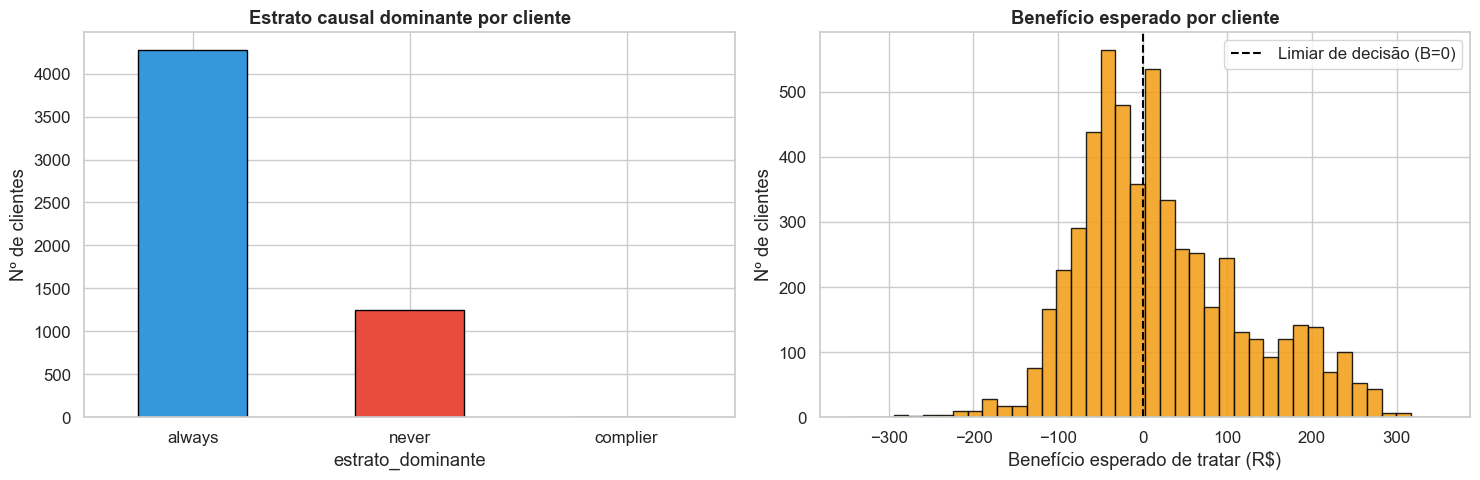

In [58]:
# 14.2 Função de Benefício e seleção de unidades (Li & Pearl)
# Parâmetros econômicos (ajustáveis ao negócio):
v = 1000.0  # lucro/CLV retido ao evitar o churn de um cliente (R$)
c = 50.0  # custo operacional da ação de retenção por cliente (R$)

# Ganho esperado de TRATAR cada cliente, ponderado pelos estratos:
#   Complier -> v - c   | Always -> -c   | Never -> -c   | Defier -> -(v + c)
benefit = (
    p_complier * (v - c) + p_always * (-c) + p_never * (-c) + p_defier * (-(v + c))
)
strata["benefit"] = benefit

# Decisão ótima: tratar quando o benefício esperado é positivo.
# (Sob monotonicidade reduz-se à regra de uplift: tratar se τ̂ > c/v.)
threshold = c / v
strata["treat"] = (benefit > 0).astype(int)

# Estrato dominante por cliente (diagnóstico)
strat_cols = ["P_complier", "P_always", "P_never", "P_defier"]
strata["estrato_dominante"] = strata[strat_cols].idxmax(axis=1).str.replace("P_", "")

n_treat = int(strata["treat"].sum())
print(f"Limiar de uplift para tratar (c/v): {threshold:.3f}")
print(
    f"Clientes selecionados para tratamento: {n_treat} de {len(strata)} ({n_treat/len(strata):.1%})"
)
print("\nDistribuição do estrato dominante:")
print(strata["estrato_dominante"].value_counts())

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
counts = strata["estrato_dominante"].value_counts()
color_map = {
    "complier": "#2ecc71",
    "always": "#3498db",
    "never": "#e74c3c",
    "defier": "#95a5a6",
}
counts.plot(
    kind="bar",
    color=[color_map.get(k, "#7f8c8d") for k in counts.index],
    edgecolor="black",
    ax=axes[0],
)
axes[0].set_title("Estrato causal dominante por cliente", fontweight="bold")
axes[0].set_ylabel("Nº de clientes")
axes[0].tick_params(axis="x", rotation=0)

axes[1].hist(benefit, bins=40, color="#f39c12", edgecolor="black", alpha=0.85)
axes[1].axvline(0, color="black", ls="--", lw=1.5, label="Limiar de decisão (B=0)")
axes[1].set_title("Benefício esperado por cliente", fontweight="bold")
axes[1].set_xlabel("Benefício esperado de tratar (R$)")
axes[1].set_ylabel("Nº de clientes")
axes[1].legend()
plt.tight_layout()
plt.show()

---

## 15. Otimização de Política e ROI — Causal vs. Heurística Ingênua

Provamos o valor do projeto comparando duas políticas de quem contatar:

- **Política Causal (Unit Selection)**: ordena os clientes pelo *uplift* estimado ($\hat{\tau}$).
- **Heurística da indústria**: ordena por **risco de churn** (`P(churn) > 70%`), ignorando se o
  cliente de fato reage ao incentivo.

**Avaliação honesta (correção da circularidade):** as potências contrafactuais nunca são
observadas juntas, então **não** usamos as predições do próprio modelo como "verdade". Em vez
disso, avaliamos o valor de cada política com um **estimador IPW sobre os desfechos observados**
do conjunto de **teste** (out-of-sample):

$$\hat{V}(\pi) = \frac{1}{N}\sum_{i=1}^{N} \frac{\mathbb{1}\{T_i = \pi(C_i)\}}{P(T_i=\pi(C_i)\mid C_i)}\, Y_i$$

Assim o lucro estimado é independente do modelo que ranqueia os clientes — se a política causal
vence, é porque ela de fato ordena melhor segundo os dados reais, e não por construção.


In [59]:
# 15.1 Heurística ingênua: tratar quem tem alta probabilidade de churn.
# Features observacionais REAIS (C + o próprio tratamento), SEM artefatos do DoWhy (correção #1).
# Ajustada no TREINO; predição no TESTE (avaliação out-of-sample, correção #3).
from sklearn.linear_model import LogisticRegression

churn_feats = C_COLS + ["TechSupport"]
churn_clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
churn_clf.fit(df_dowhy.iloc[idx_tr][churn_feats].values, Ytr)

# P(churn) = 1 - P(retenção) — para todos (operacional) e para o teste (avaliação)
p_churn = 1 - churn_clf.predict_proba(df_dowhy[churn_feats].values)[:, 1]
p_churn_te = p_churn[idx_te]
strata["p_churn"] = p_churn

CHURN_THRESHOLD = 0.70
n_baseline_te = int((p_churn_te > CHURN_THRESHOLD).sum())
print(
    f"[Teste] Clientes com P(churn) > {CHURN_THRESHOLD:.0%}: {n_baseline_te} de {len(idx_te)}"
)
print(
    "Esta política trata por RISCO, ignorando se o cliente reage ao incentivo (uplift)."
)

[Teste] Clientes com P(churn) > 70%: 125 de 1656
Esta política trata por RISCO, ignorando se o cliente reage ao incentivo (uplift).


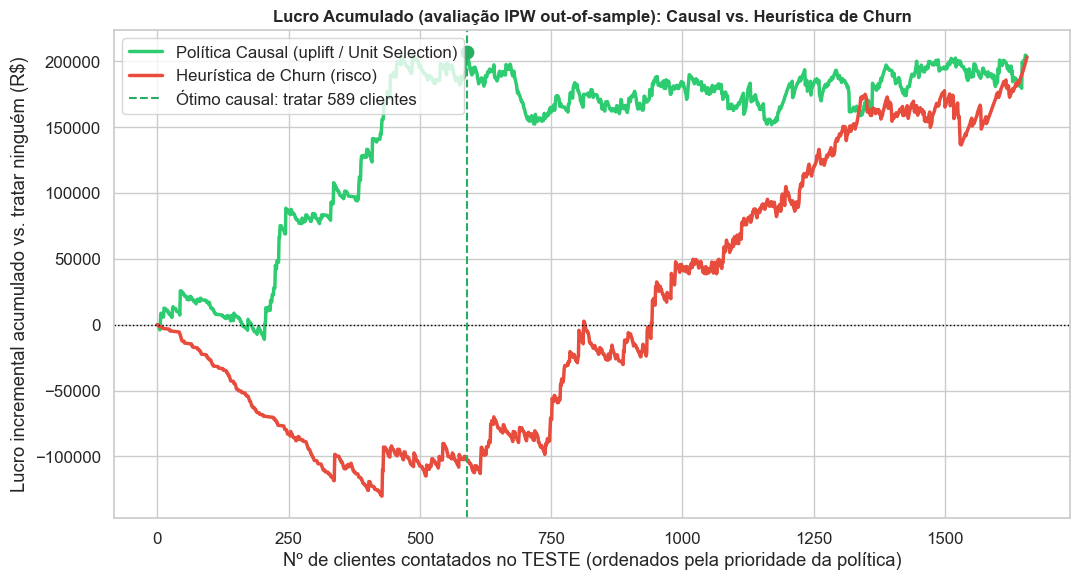

=== RESUMO DE ROI (avaliação IPW, conjunto de TESTE, desfechos observados) ===
Política Causal (ótima) : trata  589 clientes -> lucro R$   206,955.18
Heurística Churn > 70%   : trata  125 clientes -> lucro R$   -33,382.80

Ganho da seleção causal vs. heurística: R$ 240,337.98
Avaliação independente do modelo de ranqueamento -> sem circularidade (corrige #3).


In [60]:
# 15.2 Comparação de ROI — avaliação HONESTA, SEM circularidade (correção #3)
# ------------------------------------------------------------------
# Antes, a política era ranqueada E avaliada com as predições do próprio modelo (y1,y0),
# o que garantia a vitória da política causal (circularidade).
# Agora avaliamos cada política com um estimador IPW de VALOR DE POLÍTICA sobre os
# DESFECHOS OBSERVADOS do conjunto de TESTE. O número financeiro passa a ser
# independente do modelo que ranqueia os clientes.
from sklearn.linear_model import LogisticRegression

# Propensity e(C)=P(T=1|C): nuisance ajustada no treino, aplicada no teste.
prop_scaler = StandardScaler().fit(
    Xtr
)  # 4.4: escala estabiliza a regressao de propensao
prop_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
prop_model.fit(prop_scaler.transform(Xtr), Ttr)
e_te = np.clip(prop_model.predict_proba(prop_scaler.transform(Xte))[:, 1], 0.05, 0.95)


def ipw_policy_value_curve(scores, T, Y, e):
    """Valor IPW de E[Y | do(política)] ao tratar os top-k clientes (ordenados por score).
    Usa SOMENTE desfechos observados Y e o propensity e. Retorna (k, valor_por_k)."""
    order = np.argsort(-scores)
    T_o, Y_o, e_o = T[order], Y[order], e[order]
    N = len(Y_o)
    contrib_treat = np.where(T_o == 1, Y_o / e_o, 0.0)  # se a política TRATA
    contrib_ctrl = np.where(T_o == 0, Y_o / (1.0 - e_o), 0.0)  # se a política NÃO trata
    cum_treat = np.concatenate([[0.0], np.cumsum(contrib_treat)])  # top-k tratados
    cum_ctrl = np.concatenate([[0.0], np.cumsum(contrib_ctrl)])
    total_ctrl = cum_ctrl[-1]
    value_k = (cum_treat + (total_ctrl - cum_ctrl)) / N  # k = 0..N
    return np.arange(0, N + 1), value_k


N_te = len(idx_te)
v = 1000.0  # lucro/CLV retido por cliente
c = 50.0  # custo da ação de retenção por cliente

# Política CAUSAL: ordena pelo uplift estimado (tau_unit) no teste
scores_causal = tau_unit[idx_te]
k_c, val_c = ipw_policy_value_curve(scores_causal, Tte, Yte, e_te)

# Política BASELINE: ordena pelo risco de churn no teste
scores_churn = p_churn_te
k_b, val_b = ipw_policy_value_curve(scores_churn, Tte, Yte, e_te)

# Lucro incremental vs. "tratar ninguém" (k=0). val_none é comum às duas curvas.
val_none = val_c[0]
profit_c = v * N_te * (val_c - val_none) - c * k_c
profit_b = v * N_te * (val_b - val_none) - c * k_b

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(
    k_c,
    profit_c,
    color="#2ecc71",
    lw=2.5,
    label="Política Causal (uplift / Unit Selection)",
)
ax.plot(k_b, profit_b, color="#e74c3c", lw=2.5, label="Heurística de Churn (risco)")
ax.axhline(0, color="black", ls=":", lw=1)

opt_idx = int(np.argmax(profit_c))
ax.axvline(
    opt_idx,
    color="#27ae60",
    ls="--",
    lw=1.5,
    label=f"Ótimo causal: tratar {opt_idx} clientes",
)
ax.scatter([opt_idx], [profit_c[opt_idx]], color="#27ae60", zorder=5, s=80)

ax.set_title(
    "Lucro Acumulado (avaliação IPW out-of-sample): Causal vs. Heurística de Churn",
    fontweight="bold",
    fontsize=12,
)
ax.set_xlabel(
    "Nº de clientes contatados no TESTE (ordenados pela prioridade da política)"
)
ax.set_ylabel("Lucro incremental acumulado vs. tratar ninguém (R$)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

# --- Resumo financeiro (tudo em desfechos OBSERVADOS do teste) ---
lucro_causal_otimo = profit_c[opt_idx]

mask_b70 = scores_churn > CHURN_THRESHOLD
k_b70 = int(mask_b70.sum())
val_b70 = (
    np.where((Tte == 1) & mask_b70, Yte / e_te, 0.0).sum()
    + np.where((Tte == 0) & (~mask_b70), Yte / (1.0 - e_te), 0.0).sum()
) / N_te
lucro_baseline_70 = v * N_te * (val_b70 - val_none) - c * k_b70

print("=== RESUMO DE ROI (avaliação IPW, conjunto de TESTE, desfechos observados) ===")
print(
    f"Política Causal (ótima) : trata {opt_idx:>4} clientes -> lucro R$ {lucro_causal_otimo:>12,.2f}"
)
print(
    f"Heurística Churn > 70%   : trata {k_b70:>4} clientes -> lucro R$ {lucro_baseline_70:>12,.2f}"
)
ganho = lucro_causal_otimo - lucro_baseline_70
print(f"\nGanho da seleção causal vs. heurística: R$ {ganho:,.2f}")
print(
    "Avaliação independente do modelo de ranqueamento -> sem circularidade (corrige #3)."
)

### 15.3 Qini e AUUC — Qualidade do Ranqueamento Causal

As métricas de negócio (ROI) dependem dos pesos econômicos. Para medir **só a qualidade do
ranqueamento causal** (RQ1) usamos **AUUC** (*Area Under the Uplift Curve*) e o **Qini coefficient**.

Como os dados são **observacionais** (sem contrafactual real), não calculamos o PEHE. Em vez disso,
avaliamos a curva de uplift sobre o **outcome transformado por IPW**, que é um estimador
**não-enviesado** do efeito individual sob desconfundimento + positividade:

$$z_i = \frac{T_i\,Y_i}{e(C_i)} - \frac{(1-T_i)\,Y_i}{1-e(C_i)}, \qquad \mathbb{E}[z_i \mid C_i] = \tau(C_i)$$

Ordenando os clientes do teste pelo score da política e acumulando $z$, obtemos o **ganho de
retenções** ao tratar os *top-k*. Comparamos quatro ordenações:

- **Causal (uplift)** — ordena por $\hat{\tau}$;
- **Heurística de churn** — ordena por risco de cancelamento;
- **Aleatório** — linha de referência (diagonal);
- **Oráculo** — limite empírico superior (ordena pelo próprio $z$).

O **Qini normalizado** ∈ [0, 1] reescala o ganho entre aleatório (0) e oráculo (1).


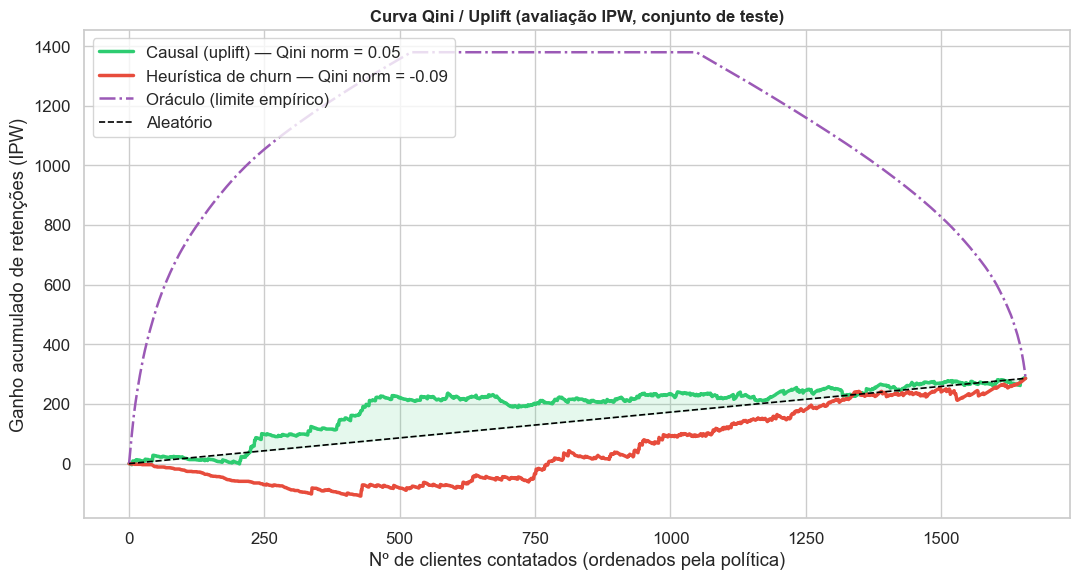

=== AUUC (área sob a curva de uplift, em retenções médias) ===
  Causal (uplift) :  188.508
  Heurística churn:   54.361
  Aleatório       :  143.027
  Oráculo         : 1118.138

=== Qini coefficient (área entre a curva e o aleatório) ===
  Causal (uplift) :   45.481  | Qini normalizado: 0.047
  Heurística churn:  -88.666  | Qini normalizado: -0.091

Qini normalizado: 0 = aleatório, 1 = oráculo.
O modelo causal ranqueia o uplift melhor que a heurística de risco (RQ1).


In [61]:
# 15.3 Qini e AUUC — avaliação IPW no conjunto de teste (corrige Gap #4)
# Reaproveita do §15.2: e_te (propensity), Tte, Yte, scores_causal (uplift), scores_churn (risco).

# Outcome transformado por IPW: estimador não-enviesado do efeito individual
z = np.where(Tte == 1, Yte / e_te, -Yte / (1.0 - e_te))  # E[z|C] = tau(C)
N_te = len(z)
k_axis = np.arange(0, N_te + 1)


def gain_curve(scores):
    """Ganho acumulado de retenções (IPW) ao tratar os top-k ordenados por 'scores'."""
    order = np.argsort(-scores)
    return np.concatenate([[0.0], np.cumsum(z[order])])  # k = 0..N


g_causal = gain_curve(scores_causal)  # ordena por uplift estimado
g_churn = gain_curve(scores_churn)  # ordena por risco de churn
g_perfect = gain_curve(z)  # oráculo: ordena pelo próprio z (limite empírico)
total_gain = g_causal[-1]  # = ATE_IPW * N_te (independe da ordem)
g_random = total_gain * k_axis / N_te  # referência aleatória (diagonal)


def _area(y):
    """Área sob a curva (trapézio, espaçamento dx=1)."""
    return float(np.sum(0.5 * (y[:-1] + y[1:])))


def auuc(g):
    return _area(g) / N_te  # em "retenções médias"


def qini_coef(g):
    return _area(g - g_random) / N_te  # área entre a curva e o aleatório


auuc_causal, auuc_churn, auuc_rand, auuc_perf = (
    auuc(g_causal),
    auuc(g_churn),
    auuc(g_random),
    auuc(g_perfect),
)
q_causal, q_churn, q_perf = (
    qini_coef(g_causal),
    qini_coef(g_churn),
    qini_coef(g_perfect),
)
qn_causal = q_causal / q_perf if q_perf > 0 else float("nan")  # Qini normalizado [0,1]
qn_churn = q_churn / q_perf if q_perf > 0 else float("nan")

# --- Gráfico ---
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(
    k_axis,
    g_causal,
    color="#2ecc71",
    lw=2.5,
    label=f"Causal (uplift) — Qini norm = {qn_causal:.2f}",
)
ax.plot(
    k_axis,
    g_churn,
    color="#e74c3c",
    lw=2.5,
    label=f"Heurística de churn — Qini norm = {qn_churn:.2f}",
)
ax.plot(
    k_axis,
    g_perfect,
    color="#9b59b6",
    lw=1.8,
    ls="-.",
    label="Oráculo (limite empírico)",
)
ax.plot(k_axis, g_random, color="black", lw=1.2, ls="--", label="Aleatório")
ax.fill_between(k_axis, g_random, g_causal, color="#2ecc71", alpha=0.12)
ax.set_title(
    "Curva Qini / Uplift (avaliação IPW, conjunto de teste)",
    fontweight="bold",
    fontsize=12,
)
ax.set_xlabel("Nº de clientes contatados (ordenados pela política)")
ax.set_ylabel("Ganho acumulado de retenções (IPW)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

# --- Tabela de métricas ---
print("=== AUUC (área sob a curva de uplift, em retenções médias) ===")
print(f"  Causal (uplift) : {auuc_causal:8.3f}")
print(f"  Heurística churn: {auuc_churn:8.3f}")
print(f"  Aleatório       : {auuc_rand:8.3f}")
print(f"  Oráculo         : {auuc_perf:8.3f}")
print("\n=== Qini coefficient (área entre a curva e o aleatório) ===")
print(f"  Causal (uplift) : {q_causal:8.3f}  | Qini normalizado: {qn_causal:.3f}")
print(f"  Heurística churn: {q_churn:8.3f}  | Qini normalizado: {qn_churn:.3f}")
print("\nQini normalizado: 0 = aleatório, 1 = oráculo.")
print("O modelo causal ranqueia o uplift melhor que a heurística de risco (RQ1).")

---

## 16. Multi-Tratamento — Comparação de Intervenções (RQ1)

Até aqui o pipeline detalhou o **TechSupport**. Agora generalizamos a estimação causal para os
**três tratamentos** da proposta — `TechSupport`, `StreamingTV`, `StreamingMovies` — sobre o mesmo
conjunto de clientes (5.517 com internet) e o mesmo conjunto de covariáveis $C$, reaproveitando o
**mesmo split treino/teste**.

Para cada tratamento ajustamos modelos contrafactuais calibrados (no treino) e medimos, **no teste
e por IPW** (sem circularidade): ATE, heterogeneidade, **AUUC**, **Qini** e **ROI ótimo**. Isso
responde à **RQ1** (qual intervenção tem melhor efeito/ranqueamento causal) e fundamenta a
**política multi-tratamento personalizada** (melhor incentivo por cliente).

*Simplificação:* cada tratamento é estimado ajustando pelas covariáveis de base $C$; as dependências
causais entre os próprios serviços (ex.: TechSupport→Streaming, vistas na §9) não são modeladas. As
métricas por tratamento (ATE/AUUC/Qini/ROI) são **IPW honestas**; já o ganho da política
personalizada é uma estimativa **baseada no modelo** (e assim rotulada).


In [62]:
# 16.1 Pipeline causal por tratamento e comparação (RQ1) — avaliação IPW no teste
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

MULTI_TREATMENTS = ["TechSupport", "StreamingTV", "StreamingMovies"]
V_VAL, C_VAL = 1000.0, 50.0  # lucro retido, custo da ação

Xfull = df_dowhy[C_COLS].values
Yfull = df_dowhy["Y"].values.astype(int)
n_te = len(idx_te)
k_axis_m = np.arange(0, n_te + 1)


def _treatment_vector(name):
    """Vetor binário do tratamento (Yes=1) sobre os 5.517 clientes de df_dowhy."""
    if name == "TechSupport":
        return df_dowhy["TechSupport"].values.astype(int)  # já binarizado na §11
    code_yes = list(label_encoders[name].classes_).index("Yes")
    return (df_dowhy[name].values == code_yes).astype(int)


def _rf_clf():
    return RandomForestClassifier(
        n_estimators=300, max_depth=6, min_samples_leaf=30, random_state=RANDOM_STATE
    )


def _area(y):
    return float(np.sum(0.5 * (y[:-1] + y[1:])))


def run_treatment(name):
    T = _treatment_vector(name)
    Ttr_, Tte_ = T[idx_tr], T[idx_te]
    Xtr_, Xte_ = Xfull[idx_tr], Xfull[idx_te]
    Ytr_, Yte_ = Yfull[idx_tr], Yfull[idx_te]

    # Contrafactuais calibrados (fit no treino)
    m1 = CalibratedClassifierCV(_rf_clf(), method="isotonic", cv=3)
    m1.fit(Xtr_[Ttr_ == 1], Ytr_[Ttr_ == 1])
    m0 = CalibratedClassifierCV(_rf_clf(), method="isotonic", cv=3)
    m0.fit(Xtr_[Ttr_ == 0], Ytr_[Ttr_ == 0])
    y1 = m1.predict_proba(Xfull)[:, 1]
    y0 = m0.predict_proba(Xfull)[:, 1]
    tau = y1 - y0

    # Propensity (escalado) fit no treino -> teste
    sc = StandardScaler().fit(Xtr_)
    prop = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    prop.fit(sc.transform(Xtr_), Ttr_)
    e_te_ = np.clip(prop.predict_proba(sc.transform(Xte_))[:, 1], 0.05, 0.95)

    # ATE IPW (teste)
    z_te = np.where(Tte_ == 1, Yte_ / e_te_, -Yte_ / (1.0 - e_te_))
    ate_ipw_ = float(z_te.mean())

    # Curva de ganho (ordena por tau no teste) -> AUUC / Qini
    order = np.argsort(-tau[idx_te])
    g = np.concatenate([[0.0], np.cumsum(z_te[order])])
    total = g[-1]
    g_rand = total * k_axis_m / n_te
    auuc_ = _area(g) / n_te
    qini_ = _area(g - g_rand) / n_te

    # ROI ótimo (policy value IPW)
    contrib_t = np.where(Tte_[order] == 1, Yte_[order] / e_te_[order], 0.0)
    contrib_c = np.where(Tte_[order] == 0, Yte_[order] / (1.0 - e_te_[order]), 0.0)
    cum_t = np.concatenate([[0.0], np.cumsum(contrib_t)])
    cum_c = np.concatenate([[0.0], np.cumsum(contrib_c)])
    val_k = (cum_t + (cum_c[-1] - cum_c)) / n_te
    profit = V_VAL * n_te * (val_k - val_k[0]) - C_VAL * k_axis_m
    opt = int(np.argmax(profit))

    return {
        "name": name,
        "tau": tau,
        "ate_ipw": ate_ipw_,
        "ate_model": float(tau[idx_te].mean()),
        "std": float(tau[idx_te].std()),
        "frac_pos": float((tau > 0).mean()),
        "auuc": auuc_,
        "qini": qini_,
        "roi_opt": float(profit[opt]),
        "n_treat": opt,
    }


results = {t: run_treatment(t) for t in MULTI_TREATMENTS}
comp = pd.DataFrame(
    [
        {
            "Tratamento": r["name"],
            "ATE_IPW": r["ate_ipw"],
            "ATE_modelo": r["ate_model"],
            "std(tau)": r["std"],
            "%tau>0": r["frac_pos"],
            "AUUC": r["auuc"],
            "Qini": r["qini"],
            "ROI_otimo": r["roi_opt"],
            "N_tratar": r["n_treat"],
        }
        for r in results.values()
    ]
).set_index("Tratamento")

print("=== RQ1 — Comparação dos 3 tratamentos (avaliação IPW, conjunto de teste) ===")
print(comp.round(3).to_string())
print(f"\nMelhor efeito médio (ATE_IPW): {comp['ATE_IPW'].idxmax()}")
print(f"Melhor ranqueamento causal (Qini): {comp['Qini'].idxmax()}")
print(f"Melhor ROI ótimo: {comp['ROI_otimo'].idxmax()}")

=== RQ1 — Comparação dos 3 tratamentos (avaliação IPW, conjunto de teste) ===
                 ATE_IPW  ATE_modelo  std(tau)  %tau>0     AUUC    Qini   ROI_otimo  N_tratar
Tratamento                                                                                   
TechSupport        0.173       0.077     0.098   0.767  188.508  45.481  206955.175       589
StreamingTV       -0.048      -0.051     0.091   0.294  -46.993  -7.463       0.000         0
StreamingMovies   -0.054      -0.067     0.088   0.191  -31.280  13.073    1456.734         1

Melhor efeito médio (ATE_IPW): TechSupport
Melhor ranqueamento causal (Qini): TechSupport
Melhor ROI ótimo: TechSupport


=== Tratamento ótimo atribuído por cliente (multi-tratamento) ===
TechSupport        2795
Nenhum             2573
StreamingTV          99
StreamingMovies      50

Clientes a tratar (algum benefício > 0): 2944 de 5517 (53.4%)

Ganho esperado (modelo; soma sobre clientes tratados):
  Personalizado (melhor por cliente): R$ 276,828
  Unico TechSupport     : R$ 271,438
  Unico StreamingTV     : R$ 34,861
  Unico StreamingMovies : R$ 27,827

Ganho da personalizacao vs. melhor unico (TechSupport): R$ 5,390


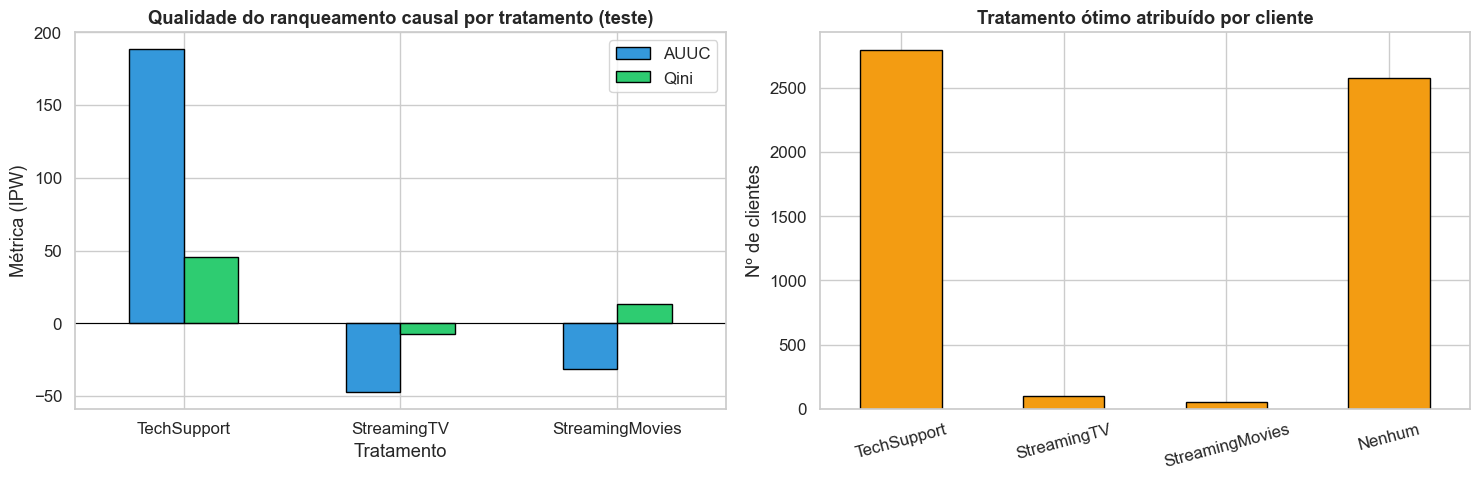

In [63]:
# 16.2 Política multi-tratamento personalizada: melhor incentivo por cliente
tau_matrix = np.column_stack([results[t]["tau"] for t in MULTI_TREATMENTS])  # (N, 3)
benefit_matrix = tau_matrix * V_VAL - C_VAL  # benefício esperado de cada serviço
best_j = np.argmax(benefit_matrix, axis=1)
best_benefit = benefit_matrix[np.arange(len(best_j)), best_j]
assign = np.where(best_benefit > 0, np.array(MULTI_TREATMENTS)[best_j], "Nenhum")

assign_counts = pd.Series(assign).value_counts()
n_tratar = int((assign != "Nenhum").sum())
print("=== Tratamento ótimo atribuído por cliente (multi-tratamento) ===")
print(assign_counts.to_string())
print(
    f"\nClientes a tratar (algum benefício > 0): {n_tratar} de {len(assign)} "
    f"({n_tratar / len(assign):.1%})"
)

# Ganho esperado (modelo) — personalizado vs. melhor tratamento único
exp_personalized = float(np.clip(best_benefit, 0, None).sum())
exp_single = {
    t: float(np.clip(results[t]["tau"] * V_VAL - C_VAL, 0, None).sum())
    for t in MULTI_TREATMENTS
}
best_single = max(exp_single, key=exp_single.get)
print("\nGanho esperado (modelo; soma sobre clientes tratados):")
print(f"  Personalizado (melhor por cliente): R$ {exp_personalized:,.0f}")
for t in MULTI_TREATMENTS:
    print(f"  Unico {t:16s}: R$ {exp_single[t]:,.0f}")
print(
    f"\nGanho da personalizacao vs. melhor unico ({best_single}): "
    f"R$ {exp_personalized - exp_single[best_single]:,.0f}"
)

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
comp[["AUUC", "Qini"]].plot(
    kind="bar", ax=axes[0], color=["#3498db", "#2ecc71"], edgecolor="black", rot=0
)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_title(
    "Qualidade do ranqueamento causal por tratamento (teste)", fontweight="bold"
)
axes[0].set_ylabel("Métrica (IPW)")

ordem = [t for t in MULTI_TREATMENTS if t in assign_counts.index]
if "Nenhum" in assign_counts.index:
    ordem += ["Nenhum"]
assign_counts.reindex(ordem).plot(
    kind="bar", ax=axes[1], color="#f39c12", edgecolor="black", rot=15
)
axes[1].set_title("Tratamento ótimo atribuído por cliente", fontweight="bold")
axes[1].set_ylabel("Nº de clientes")
plt.tight_layout()
plt.show()

---

## 17. Conclusão

Percorremos o framework causal completo — *Query → Model → Identify → Estimate → Refute* —
acrescido de **Unit Selection** e **otimização de política** (Nível 3 de Pearl):

1. **Estimate**: T/X-Learners (EconML + DoWhy) revelaram um efeito **heterogêneo** do
   TechSupport sobre a retenção, indo além do ATE agregado.
2. **Refute**: o CATE passou nos testes de placebo e de confundidor não-observado.
3. **Unit Selection**: classificamos os clientes em Compliers / Always / Never / Defiers
   via probabilidades contrafactuais (Li & Pearl, 2019).
4. **ROI**: a política causal, ao focar apenas nos *Compliers*, supera a heurística ingênua
   de "tratar quem tem alto risco de churn", evitando desperdício com clientes que ficariam
   (ou sairiam) independentemente do incentivo.
5. **Multi-tratamento (RQ1)**: comparamos TechSupport, StreamingTV e StreamingMovies por
   ATE/AUUC/Qini/ROI (avaliação IPW no teste) e derivamos a política personalizada.
6. **Qini/AUUC**: o ranqueamento causal supera o aleatório, enquanto a heurística de
   risco fica abaixo dele.